# Топливный кризис 2026 — FINAL SORTING & VALIDATION

**Пересборка классификации периодов с нуля. Кризис начинается в МАЕ 2026.**

Этот ноутбук — единственный источник истины (source of truth) для финального
отсортированного датасета. Весь путь `сырые данные → очистка → разбор дат →
классификация периодов → валидация → экспорт → аудит-лог` выполняется здесь,
сверху вниз, на чистом ядре, без внешних скриптов.

---

### Почему пересборка

Предыдущая версия сортировки использовала границу кризиса **2026-06-19**
(точка структурного разрыва, найденная по данным). Это ошибка относительно
постановки задачи: организаторы прямо пишут «**Начало кризиса: май 2026**».
Граница пересчитана на **май** и заново применена к **сырым** данным —
не к ранее отсортированному выводу.

### Что производится

| Файл | Содержание |
|---|---|
| `FINAL_SORTED_DATA.csv` | Главный результат: все события (заправки + штрафы) в одной длинной таблице, отсортированы хронологически, у каждого — метка периода |
| `FINAL_SORTED_FINES.csv` | Таблица 2 (штрафы), очищенная + классифицированная |
| `FINAL_SORTED_FUEL.csv` | Таблица 3 (транзакции АЗС), очищенная + классифицированная |
| `FINAL_CLIENT_PERIOD_PANEL.csv` | Панель «клиент × период» — готова для модели |
| `FINAL_DAILY_SERIES.csv` | Дневные агрегаты обеих таблиц |
| `FINAL_BOUNDARY_VALIDATION.csv` | Таблица периодов: period / start / end / n_rows |
| `FINAL_SORTING_AUDIT.md` | Аудит-лог, генерируется этим ноутбуком |
| `figures/*.png` | Графики валидации |

**Сырые CSV никогда не перезаписываются** — это проверяется хешами в начале и в конце.

## 1. Импорты и конфигурация

Здесь фиксируется всё, что влияет на результат: версии библиотек, пути,
константы границы кризиса и окон анализа. Ни одна из этих величин
дальше по ноутбуку не переопределяется «на лету».

In [1]:
import hashlib
import json
import platform
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUN_STARTED_AT = datetime.now().astimezone()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 60)

matplotlib.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'figure.autolayout': True,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})

ENVIRONMENT = {
    'run_started_at': RUN_STARTED_AT.isoformat(timespec='seconds'),
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'matplotlib': matplotlib.__version__,
}
for k, v in ENVIRONMENT.items():
    print(f'{k:>16}: {v}')

  run_started_at: 2026-09-19T22:49:44+03:00
          python: 3.14.6
        platform: macOS-26.6.2-arm64-arm-64bit-Mach-O
          pandas: 3.0.5
           numpy: 2.5.1
      matplotlib: 3.11.1


In [2]:
# --- Пути (воспроизводимые, без абсолютных хардкодов вне BASE_DIR) ----------
BASE_DIR = Path.home() / 'Desktop' / 'DANO dataset'

RAW_CLIENTS_PATH = BASE_DIR / 'clients_demographics.csv'   # Таблица 1
RAW_FINES_PATH   = BASE_DIR / 'fines_2026.csv'             # Таблица 2
RAW_FUEL_PATH    = BASE_DIR / 'fuel_transaction.csv'       # Таблица 3

NOTEBOOK_NAME = 'FINAL_SORTING_AND_VALIDATION.ipynb'

OUT_DIR = BASE_DIR / 'FINAL_OUTPUT'
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATHS = {
    'clients_demographics.csv': RAW_CLIENTS_PATH,
    'fines_2026.csv': RAW_FINES_PATH,
    'fuel_transaction.csv': RAW_FUEL_PATH,
}

for name, p in RAW_PATHS.items():
    assert p.exists(), f'Сырой файл не найден: {p}'

# Защита от перезаписи сырых данных: выходной каталог не должен их содержать.
assert OUT_DIR.resolve() not in {p.resolve().parent for p in RAW_PATHS.values()}, \
    'OUT_DIR совпадает с каталогом сырых данных — экспорт мог бы их затереть.'

print('BASE_DIR:', BASE_DIR)
print('OUT_DIR :', OUT_DIR)
print('FIG_DIR :', FIG_DIR)

BASE_DIR: /Users/markmitrofanov/Desktop/DANO dataset
OUT_DIR : /Users/markmitrofanov/Desktop/DANO dataset/FINAL_OUTPUT
FIG_DIR : /Users/markmitrofanov/Desktop/DANO dataset/FINAL_OUTPUT/figures


In [3]:
# --- ГРАНИЦА КРИЗИСА -------------------------------------------------------
# Источник: «Презентация задания new.pdf» — «Начало кризиса: май 2026».
# Решение: intervention boundary = НАЧАЛО МАЯ 2026, полночь.
CRISIS_START = pd.Timestamp('2026-05-01 00:00:00')

# Уточнение фаз внутри кризиса (Задание.pdf: «С конца мая 2026 года ...
# начали вводиться ограничения», «К середине июня ограничения затронули
# значительную часть субъектов РФ»). Фазы НЕ меняют деление pre/crisis —
# это дополнительный, более тонкий срез внутри кризисного периода.
PHASE_ONSET_START = pd.Timestamp('2026-05-01 00:00:00')  # май, начало кризиса
PHASE_RAMP_START  = pd.Timestamp('2026-05-25 00:00:00')  # «конец мая»
PHASE_FULL_START  = pd.Timestamp('2026-06-15 00:00:00')  # «середина июня»

# Альтернативные границы — только для проверки устойчивости (robustness),
# основная классификация по ним НЕ строится.
SENSITIVITY_BOUNDARIES = {
    'may_01_primary':      pd.Timestamp('2026-05-01'),
    'may_25_late_may':     pd.Timestamp('2026-05-25'),
    'jun_15_mid_june':     pd.Timestamp('2026-06-15'),
    'jun_19_previous_run': pd.Timestamp('2026-06-19'),  # ошибочная старая граница
}

PERIOD_LABELS = ['pre_crisis', 'crisis']
PHASE_LABELS  = ['pre_crisis', 'crisis_onset_may', 'crisis_ramp_late_may', 'crisis_full_from_mid_june']

print('CRISIS_START      =', CRISIS_START)
print('фазы:', PHASE_ONSET_START.date(), PHASE_RAMP_START.date(), PHASE_FULL_START.date())

CRISIS_START      = 2026-05-01 00:00:00
фазы: 2026-05-01 2026-05-25 2026-06-15


In [4]:
# AUDIT — накопитель фактов для аудит-лога. Всё, что попадёт в
# FINAL_SORTING_AUDIT.md, складывается сюда ИЗ РЕЗУЛЬТАТОВ ВЫПОЛНЕНИЯ,
# а не набирается руками.
AUDIT = {'environment': ENVIRONMENT}
VALIDATIONS = []   # список словарей: id, description, passed, detail


def record(section, **facts):
    'Записать факты в аудит-лог.'
    AUDIT.setdefault(section, {}).update(facts)
    return facts


def check(check_id, description, condition, detail=''):
    'Проверка с жёстким провалом: ноутбук должен упасть, а не молча отдать плохой датасет.'
    passed = bool(condition)
    VALIDATIONS.append({'id': check_id, 'description': description,
                        'passed': passed, 'detail': str(detail)})
    status = 'PASS' if passed else 'FAIL'
    print(f'[{status}] {check_id}: {description}' + (f'  |  {detail}' if detail else ''))
    if not passed:
        raise AssertionError(f'{check_id} FAILED: {description} | {detail}')
    return passed


print('Регистраторы аудита готовы.')

Регистраторы аудита готовы.


## 2. Загрузка сырых данных

Читаем три исходных CSV **как есть**. Особенности формата: разделитель `;`,
десятичная запятая. Колонки с датами читаются **как строки** — разбор дат
выполняется отдельным явным шагом в разделе 5, чтобы ни одна дата
не была «угадана» молча парсером.

Для каждого файла считается SHA-256 — тот же хеш пересчитывается в конце
ноутбука, чтобы доказать, что сырые файлы не изменялись.

In [5]:
def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as fh:
        for block in iter(lambda: fh.read(chunk), b''):
            h.update(block)
    return h.hexdigest()


RAW_HASHES_BEFORE = {name: sha256_of(p) for name, p in RAW_PATHS.items()}
RAW_FILE_INFO = pd.DataFrame([
    {'file': name,
     'bytes': p.stat().st_size,
     'modified': datetime.fromtimestamp(p.stat().st_mtime).isoformat(timespec='seconds'),
     'sha256': RAW_HASHES_BEFORE[name]}
    for name, p in RAW_PATHS.items()
])
RAW_FILE_INFO

,file,bytes,modified,sha256
0,clients_demographics.csv,4579092,2026-09-19T11:35:13,c41797f050d28474b791b122e141615036d9d8768ab7b96249082342...
1,fines_2026.csv,16750636,2026-09-19T11:35:38,1de7495a11ac47277b90511a13314a5c3cf44b91037b935d5047efb5...
2,fuel_transaction.csv,38639069,2026-09-19T11:37:10,977e9a2d517512491d98ec55f9672206c74676db2a1533276ff96f55...


In [6]:
# Таблица 1 — демография клиентов (одна строка на АВТОМОБИЛЬ, не на клиента)
raw_clients = pd.read_csv(
    RAW_CLIENTS_PATH, sep=';', decimal=',',
    dtype={'client_id': 'str', 'auto_document_id': 'str',
           'subscription_creation_date': 'str', 'kladr_code': 'Int64'},
)

# Таблица 2 — штрафы 2026
raw_fines = pd.read_csv(
    RAW_FINES_PATH, sep=';', decimal=',',
    dtype={'client_id': 'str', 'bill_id': 'str', 'auto_document_id': 'str',
           'bill_offence_date': 'str', 'total_fine_amount': 'Int64'},
)

# Таблица 3 — транзакции на АЗС
raw_fuel = pd.read_csv(
    RAW_FUEL_PATH, sep=';', decimal=',',
    dtype={'order_id': 'str', 'client_id': 'str', 'order_datetime': 'str'},
)

RAW_ROWS = {
    'clients_demographics.csv': len(raw_clients),
    'fines_2026.csv': len(raw_fines),
    'fuel_transaction.csv': len(raw_fuel),
}
record('raw_input', files={k: str(v) for k, v in RAW_PATHS.items()},
       row_counts=RAW_ROWS, sha256=RAW_HASHES_BEFORE)

for k, v in RAW_ROWS.items():
    print(f'{k:>28}: {v:>8,} строк')

    clients_demographics.csv:   28,237 строк
              fines_2026.csv:   77,978 строк
        fuel_transaction.csv:  379,699 строк


## 3. Первичный осмотр

Цель раздела — зафиксировать исходное состояние до любых преобразований:
типы, пропуски, дубликаты, связи между таблицами. Все числа отсюда
попадают в аудит-лог и служат точкой отсчёта для сверки строк в разделе 8.

In [7]:
def profile(df, name):
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(3),
        'n_unique': df.nunique(dropna=True),
    })
    out.index.name = f'{name} ({len(df):,} строк)'
    return out


display(profile(raw_clients, 'clients_demographics'))
display(profile(raw_fines, 'fines_2026'))
display(profile(raw_fuel, 'fuel_transaction'))

,dtype,n_missing,pct_missing,n_unique
"clients_demographics (28,237 строк)",,,,
client_id,str,0,0.000,25675
gender,str,42,0.149,2
age_type_code,str,2,0.007,4
auto_document_id,str,0,0.000,28093
auto_mark,str,0,0.000,137
auto_year,int64,0,0.000,46
engine_type,str,2,0.007,1457
price,float64,631,2.235,4381
color,str,1408,4.986,442


,dtype,n_missing,pct_missing,n_unique
"fines_2026 (77,978 строк)",,,,
client_id,str,0,0.0,15503
bill_id,str,0,0.0,77978
offence_short_statement,str,0,0.0,25
total_fine_amount,Int64,0,0.0,18
region_name,str,0,0.0,77
bill_offence_date,str,0,0.0,77606
auto_document_id,str,0,0.0,16452


,dtype,n_missing,pct_missing,n_unique
"fuel_transaction (379,699 строк)",,,,
order_id,str,0,0.0,379699
order_datetime,str,0,0.0,379696
order_fuel_volume,float64,0,0.0,9639
order_fuel_price_1liter,float64,0,0.0,4403
client_id,str,0,0.0,25675


In [8]:
# --- Дубликаты в сыром виде -------------------------------------------------
dup_report = pd.DataFrame([
    {'table': 'clients_demographics', 'key': 'client_id',
     'n_dup_key': int(raw_clients['client_id'].duplicated().sum()),
     'n_dup_full_row': int(raw_clients.duplicated().sum())},
    {'table': 'clients_demographics', 'key': 'client_id+auto_document_id',
     'n_dup_key': int(raw_clients.duplicated(['client_id', 'auto_document_id']).sum()),
     'n_dup_full_row': int(raw_clients.duplicated().sum())},
    {'table': 'fines_2026', 'key': 'bill_id',
     'n_dup_key': int(raw_fines['bill_id'].duplicated().sum()),
     'n_dup_full_row': int(raw_fines.duplicated().sum())},
    {'table': 'fuel_transaction', 'key': 'order_id',
     'n_dup_key': int(raw_fuel['order_id'].duplicated().sum()),
     'n_dup_full_row': int(raw_fuel.duplicated().sum())},
])
record('raw_duplicates', table=dup_report.to_dict('records'))
dup_report

,table,key,n_dup_key,n_dup_full_row
0,clients_demographics,client_id,2562,0
1,clients_demographics,client_id+auto_document_id,47,0
2,fines_2026,bill_id,0,0
3,fuel_transaction,order_id,0,0


**Читаем результат.** `client_id` в таблице 1 дублируется — это **не** грязные
данные: у одного клиента может быть несколько автомобилей, и таблица 1
заведена на уровне «клиент × автомобиль». Пара `client_id + auto_document_id`
уникальна. Отсюда следует важное правило для всего дальнейшего:

* к штрафам демография подсоединяется по `(client_id, auto_document_id)`;
* к заправкам (там есть только `client_id`) — по **клиентской** таблице,
  свёрнутой к одной строке на клиента, иначе заправки мультиплицируются
  у владельцев нескольких машин.

In [9]:
# --- Связность ключей -------------------------------------------------------
cars_per_client = raw_clients.groupby('client_id').size()
link_report = {
    'n_rows_clients_table': len(raw_clients),
    'n_unique_client_id': int(raw_clients['client_id'].nunique()),
    'n_unique_auto_document_id': int(raw_clients['auto_document_id'].nunique()),
    'max_cars_per_client': int(cars_per_client.max()),
    'n_clients_with_multiple_cars': int((cars_per_client > 1).sum()),
    'fines_client_id_in_demographics_pct': round(float(raw_fines['client_id'].isin(raw_clients['client_id']).mean() * 100), 4),
    'fines_auto_doc_in_demographics_pct': round(float(raw_fines['auto_document_id'].isin(raw_clients['auto_document_id']).mean() * 100), 4),
    'fuel_client_id_in_demographics_pct': round(float(raw_fuel['client_id'].isin(raw_clients['client_id']).mean() * 100), 4),
    'n_clients_with_fines': int(raw_fines['client_id'].nunique()),
    'n_clients_with_fuel': int(raw_fuel['client_id'].nunique()),
}
record('key_linkage', **link_report)
pd.Series(link_report).to_frame('value')

,value
n_rows_clients_table,28237.0
n_unique_client_id,25675.0
n_unique_auto_document_id,28093.0
max_cars_per_client,16.0
n_clients_with_multiple_cars,2301.0
fines_client_id_in_demographics_pct,100.0
fines_auto_doc_in_demographics_pct,100.0
fuel_client_id_in_demographics_pct,100.0
n_clients_with_fines,15503.0
n_clients_with_fuel,25675.0


## 4. Очистка данных

Принцип раздела: **строки не удаляются**. Всё подозрительное помечается
булевыми флагами, и дальше решение «включать / не включать» принимается
явно и видно в данных. Это единственный способ гарантировать сверку
`строк на входе == строк на выходе`.

Что делается:
1. `total_fine_amount` — по спецификации в **копейках** → отдельная колонка в рублях;
2. текстовые поля — обрезка пробелов (без изменения смысла категорий);
3. числовые поля топлива — проверка на неположительные / экстремальные значения;
4. таблица 1 сворачивается к уровню клиента с проверкой, что демографические
   признаки внутри клиента действительно постоянны.

In [10]:
# --- Таблица 2: штрафы ------------------------------------------------------
fines = raw_fines.copy()

fines['offence_short_statement'] = fines['offence_short_statement'].str.strip()
fines['region_name'] = fines['region_name'].str.strip()

# Спецификация: total_fine_amount — полная сумма штрафа В КОПЕЙКАХ.
fines['fine_amount_rub'] = fines['total_fine_amount'].astype('Float64') / 100.0

fines['flag_nonpositive_amount'] = ~(fines['fine_amount_rub'] > 0)

fines_clean_report = {
    'n_rows': len(fines),
    'n_nonpositive_amount': int(fines['flag_nonpositive_amount'].sum()),
    'amount_rub_min': float(fines['fine_amount_rub'].min()),
    'amount_rub_median': float(fines['fine_amount_rub'].median()),
    'amount_rub_max': float(fines['fine_amount_rub'].max()),
    'n_offence_categories': int(fines['offence_short_statement'].nunique()),
    'n_regions': int(fines['region_name'].nunique()),
}
record('cleaning_fines', **fines_clean_report)
pd.Series(fines_clean_report).to_frame('value')

,value
n_rows,77978.0
n_nonpositive_amount,0.0
amount_rub_min,500.0
amount_rub_median,750.0
amount_rub_max,10000.0
n_offence_categories,25.0
n_regions,77.0


In [11]:
# --- Таблица 3: транзакции АЗС ---------------------------------------------
fuel = raw_fuel.copy()

fuel['order_fuel_volume'] = pd.to_numeric(fuel['order_fuel_volume'], errors='coerce')
fuel['order_fuel_price_1liter'] = pd.to_numeric(fuel['order_fuel_price_1liter'], errors='coerce')

# Стоимость чека — производная величина, понадобится для панели.
fuel['fuel_cost_rub'] = (fuel['order_fuel_volume'] * fuel['order_fuel_price_1liter']).round(2)

# Флаги физически сомнительных значений. Пороги — не «магия»: бак легковой
# машины практически не превышает 100 л, розничная цена литра в 2026 г.
# лежит далеко внутри 10–200 руб.
fuel['flag_negative_volume'] = fuel['order_fuel_volume'] < 0
fuel['flag_bad_volume'] = ~fuel['order_fuel_volume'].between(0.01, 100.0, inclusive='both')
fuel['flag_bad_price'] = ~fuel['order_fuel_price_1liter'].between(10.0, 200.0, inclusive='both')

# Сегмент цены: распределение цены литра ЯВНО многомодально — отдельный
# кластер около 20–40 ₽ (похоже на газовое топливо, ГБО) и тяжёлый хвост
# выше 150 ₽. Сравнивать средние цены, не удерживая сегмент, некорректно.
fuel['price_segment'] = pd.cut(
    fuel['order_fuel_price_1liter'], bins=[-np.inf, 45, 150, np.inf],
    labels=['lpg_like_under_45', 'standard_45_150', 'extreme_over_150'])

# Строка годна для ИЗМЕРЕНИЙ (объём/цена/сумма), но остаётся в датасете в любом случае.
fuel['valid_measurement'] = ~(fuel['flag_bad_volume'] | fuel['flag_bad_price'])

fuel_clean_report = {
    'n_rows': len(fuel),
    'n_volume_na': int(fuel['order_fuel_volume'].isna().sum()),
    'n_price_na': int(fuel['order_fuel_price_1liter'].isna().sum()),
    'n_flag_negative_volume': int(fuel['flag_negative_volume'].sum()),
    'n_flag_bad_volume': int(fuel['flag_bad_volume'].sum()),
    'n_flag_bad_price': int(fuel['flag_bad_price'].sum()),
    'n_valid_measurement': int(fuel['valid_measurement'].sum()),
    'pct_valid_measurement': round(float(fuel['valid_measurement'].mean() * 100), 3),
    'volume_min': float(fuel['order_fuel_volume'].min()),
    'volume_max': float(fuel['order_fuel_volume'].max()),
    'price_min': float(fuel['order_fuel_price_1liter'].min()),
    'price_max': float(fuel['order_fuel_price_1liter'].max()),
    'price_segments': {str(k): int(v) for k, v in
                       fuel['price_segment'].value_counts().items()},
}
record('cleaning_fuel', **fuel_clean_report)
pd.Series(fuel_clean_report).to_frame('value')

,value
n_rows,379699
n_volume_na,0
n_price_na,0
n_flag_negative_volume,1500
n_flag_bad_volume,2560
n_flag_bad_price,2329
n_valid_measurement,374810
pct_valid_measurement,98.712
volume_min,-164.03
volume_max,505.62


**Аномалия №2 — сомнительные измерения в таблице 3.** Проверка обнаружила
в сырых данных: строки с **отрицательным объёмом** (похоже на возвраты/сторно),
строки с объёмом свыше 100 л и тяжёлый правый хвост цены. Дополнительно цена
литра распределена **многомодально**: есть обособленный кластер около 20–40 ₽
(характерно для газового топлива) — его нельзя смешивать с бензином при
сравнении средних цен.

Решение: строки **сохраняются**, но получают флаг `valid_measurement`.
Периодизация от этого не зависит (она определяется только датой), а вот
суммы литров и средние цены считаются **только по строкам с корректным
измерением** — иначе сторно-строки давали бы отрицательные объёмы у клиентов.
Для прозрачности в панель добавлена и «сырая» знаковая сумма
`fuel_volume_l_net_all`, включающая возвраты.

In [12]:
# --- Таблица 1: свёртка к уровню клиента -----------------------------------
KLADR_TO_REGION = {
    77: 'Москва', 50: 'Московская область', 78: 'Санкт-Петербург',
    16: 'Республика Татарстан', 66: 'Свердловская область',
    54: 'Новосибирская область', 47: 'Ленинградская область',
    52: 'Нижегородская область', 23: 'Краснодарский край',
    63: 'Самарская область', 74: 'Челябинская область',
    42: 'Кемеровская область', 72: 'Тюменская область',
    2: 'Республика Башкортостан', 24: 'Красноярский край', 55: 'Омская область',
}

clients_cars = raw_clients.copy()          # уровень «клиент × автомобиль»
clients_cars['home_region'] = clients_cars['kladr_code'].map(KLADR_TO_REGION)

check('V0.1', 'все kladr_code расшифрованы справочником из ТЗ',
      clients_cars['home_region'].notna().all(),
      detail=f"нерасшифровано: {int(clients_cars['home_region'].isna().sum())}")

# Признаки, которые ОБЯЗАНЫ быть постоянны внутри client_id, — проверяем, а не предполагаем.
CLIENT_CONSTANT_COLS = ['gender', 'age_type_code', 'kladr_code', 'home_region']
nonconstant = {c: int((clients_cars.groupby('client_id')[c].nunique(dropna=False) > 1).sum())
               for c in CLIENT_CONSTANT_COLS}
record('cleaning_clients', nonconstant_within_client=nonconstant)
check('V0.2', 'gender / age_type_code / kladr_code постоянны внутри client_id',
      all(v == 0 for v in nonconstant.values()), detail=str(nonconstant))

[PASS] V0.1: все kladr_code расшифрованы справочником из ТЗ  |  нерасшифровано: 0
[PASS] V0.2: gender / age_type_code / kladr_code постоянны внутри client_id  |  {'gender': 0, 'age_type_code': 0, 'kladr_code': 0, 'home_region': 0}


True

In [13]:
# Свёртка: демография — первое (и единственное) значение, «автомобильные»
# признаки — агрегаты, счётчики штрафов 2025 — СУММА по всем машинам клиента.
FINES_2025_COLS = ['april_2025_fines', 'may_2025_fines', 'jun_2025_fines',
                   'jul_2025_fines', 'aug_2025_fines']
FINES_HIST_COLS = ['fines_last_6_month', 'fines_last_12_month',
                   'fines_last_24_month', 'fines_last_36_month']

clients = (
    clients_cars
    .groupby('client_id', as_index=False)
    .agg(
        gender=('gender', 'first'),
        age_type_code=('age_type_code', 'first'),
        kladr_code=('kladr_code', 'first'),
        home_region=('home_region', 'first'),
        n_cars=('auto_document_id', 'nunique'),
        auto_year_max=('auto_year', 'max'),
        auto_price_total=('price', 'sum'),
        **{c: (c, 'sum') for c in FINES_2025_COLS + FINES_HIST_COLS},
    )
)
clients['fines_2025_apr_aug'] = clients[FINES_2025_COLS].sum(axis=1)

check('V0.3', 'клиентская таблица содержит ровно по одной строке на client_id',
      (len(clients) == raw_clients['client_id'].nunique()) and not clients['client_id'].duplicated().any(),
      detail=f'{len(clients):,} строк = {raw_clients["client_id"].nunique():,} уникальных клиентов')

record('cleaning_clients', n_client_rows=len(clients),
       n_car_rows=len(clients_cars),
       columns_created_clients=['home_region', 'n_cars', 'auto_year_max',
                                'auto_price_total', 'fines_2025_apr_aug'])
clients.head()

[PASS] V0.3: клиентская таблица содержит ровно по одной строке на client_id  |  25,675 строк = 25,675 уникальных клиентов


,client_id,gender,age_type_code,kladr_code,home_region,n_cars,auto_year_max,auto_price_total,april_2025_fines,may_2025_fines,jun_2025_fines,jul_2025_fines,aug_2025_fines,fines_last_6_month,fines_last_12_month,fines_last_24_month,fines_last_36_month,fines_2025_apr_aug
0,00049004b7a7343f78e9102655724e90,M,A40,78,Санкт-Петербург,2,2024,5236099.0,0,2,0,0,2,0,8,8,8,4
1,000785004fc8858930fba388ae2753a8,M,A20,54,Новосибирская область,2,2017,2750770.0,1,0,0,1,1,1,5,5,11,3
2,0008bb56f8889602d088e86dbd9dc472,M,A20,77,Москва,1,2016,1367490.0,0,2,1,2,0,9,17,17,17,5
3,0008ca8e3bbd513d755f479af00c31e2,M,A40,74,Челябинская область,1,2007,1335714.0,0,0,0,0,0,2,4,4,6,0
4,00093f3709c78522d2b7877db9659082,M,A40,66,Свердловская область,2,2010,2055000.0,0,1,1,0,0,4,6,8,8,2


## 5. Разбор дат

Это критический раздел: именно здесь решается, к какому периоду попадёт строка.
Правила разбора задаются **явно**, автоопределение формата не используется.

| Таблица | Колонка | Формат | Тип |
|---|---|---|---|
| Таблица 2, штрафы | `bill_offence_date` | `%Y-%m-%d %H:%M:%S` | дата-время нарушения (naive, без таймзоны) |
| Таблица 3, АЗС | `order_datetime` | `%Y-%m-%d %H:%M:%S.%f` | дата-время заказа с миллисекундами |
| Таблица 1, клиенты | `subscription_creation_date` | `%Y-%m-%d` | дата, без времени |

Политика разбора:
* `errors='coerce'` → всё, что не разобралось, становится `NaT` и **пересчитывается**,
  а не исчезает молча;
* таймзоны в данных отсутствуют → все метки трактуются как локальное время
  без сдвига; сравнение с границей кризиса идёт в той же шкале;
* «невозможные» даты (вне диапазона выгрузки, в будущем относительно
  последнего наблюдения) помечаются флагом и разбираются ниже.

In [14]:
FINES_DATE_FORMAT = '%Y-%m-%d %H:%M:%S'
FUEL_DATE_FORMAT = '%Y-%m-%d %H:%M:%S.%f'
CLIENT_DATE_FORMAT = '%Y-%m-%d'

fines['event_datetime'] = pd.to_datetime(
    fines['bill_offence_date'], format=FINES_DATE_FORMAT, errors='coerce')
fuel['event_datetime'] = pd.to_datetime(
    fuel['order_datetime'], format=FUEL_DATE_FORMAT, errors='coerce')
clients_cars['subscription_date'] = pd.to_datetime(
    clients_cars['subscription_creation_date'], format=CLIENT_DATE_FORMAT, errors='coerce')

# Строки, где исходная строка непустая, а дата не разобралась = malformed.
fines['flag_malformed_date'] = fines['event_datetime'].isna() & fines['bill_offence_date'].notna()
fines['flag_missing_date'] = fines['bill_offence_date'].isna()
fuel['flag_malformed_date'] = fuel['event_datetime'].isna() & fuel['order_datetime'].notna()
fuel['flag_missing_date'] = fuel['order_datetime'].isna()

date_parse_report = pd.DataFrame([
    {'table': 'fines_2026', 'column': 'bill_offence_date', 'format': FINES_DATE_FORMAT,
     'n_rows': len(fines),
     'n_missing_raw': int(fines['flag_missing_date'].sum()),
     'n_malformed': int(fines['flag_malformed_date'].sum()),
     'n_parsed_ok': int(fines['event_datetime'].notna().sum())},
    {'table': 'fuel_transaction', 'column': 'order_datetime', 'format': FUEL_DATE_FORMAT,
     'n_rows': len(fuel),
     'n_missing_raw': int(fuel['flag_missing_date'].sum()),
     'n_malformed': int(fuel['flag_malformed_date'].sum()),
     'n_parsed_ok': int(fuel['event_datetime'].notna().sum())},
    {'table': 'clients_demographics', 'column': 'subscription_creation_date', 'format': CLIENT_DATE_FORMAT,
     'n_rows': len(clients_cars),
     'n_missing_raw': int(clients_cars['subscription_creation_date'].isna().sum()),
     'n_malformed': int((clients_cars['subscription_date'].isna() &
                         clients_cars['subscription_creation_date'].notna()).sum()),
     'n_parsed_ok': int(clients_cars['subscription_date'].notna().sum())},
])
record('date_parsing',
       formats={'fines_2026.bill_offence_date': FINES_DATE_FORMAT,
                'fuel_transaction.order_datetime': FUEL_DATE_FORMAT,
                'clients_demographics.subscription_creation_date': CLIENT_DATE_FORMAT},
       policy='pd.to_datetime(errors="coerce"); NaT пересчитывается; таймзона отсутствует, сдвиг не применяется',
       report=date_parse_report.to_dict('records'))
date_parse_report

,table,column,format,n_rows,n_missing_raw,n_malformed,n_parsed_ok
0,fines_2026,bill_offence_date,%Y-%m-%d %H:%M:%S,77978,0,0,77978
1,fuel_transaction,order_datetime,%Y-%m-%d %H:%M:%S.%f,379699,0,0,379699
2,clients_demographics,subscription_creation_date,%Y-%m-%d,28237,0,0,28237


In [15]:
# --- Наблюдаемые окна и дата выгрузки --------------------------------------
windows = pd.DataFrame([
    {'table': 'fines_2026', 'column': 'bill_offence_date',
     'min': fines['event_datetime'].min(), 'max': fines['event_datetime'].max()},
    {'table': 'fuel_transaction', 'column': 'order_datetime',
     'min': fuel['event_datetime'].min(), 'max': fuel['event_datetime'].max()},
])

# Последнее событие во всех данных ≈ момент выгрузки. Всё, что «после» — невозможно.
DATA_EXTRACT_AT = max(fines['event_datetime'].max(), fuel['event_datetime'].max())
PLAUSIBLE_MIN = pd.Timestamp('2026-01-01')

for df in (fines, fuel):
    df['flag_impossible_date'] = (
        df['event_datetime'].notna()
        & ((df['event_datetime'] < PLAUSIBLE_MIN) | (df['event_datetime'] > DATA_EXTRACT_AT))
    )

record('observed_windows',
       fines_min=str(fines['event_datetime'].min()), fines_max=str(fines['event_datetime'].max()),
       fuel_min=str(fuel['event_datetime'].min()), fuel_max=str(fuel['event_datetime'].max()),
       data_extract_at=str(DATA_EXTRACT_AT),
       n_impossible_fines=int(fines['flag_impossible_date'].sum()),
       n_impossible_fuel=int(fuel['flag_impossible_date'].sum()))

print('Последнее событие в данных (≈ момент выгрузки):', DATA_EXTRACT_AT)
print('Невозможных дат: штрафы =', int(fines['flag_impossible_date'].sum()),
      ', заправки =', int(fuel['flag_impossible_date'].sum()))
windows

Последнее событие в данных (≈ момент выгрузки): 2026-09-14 15:54:01
Невозможных дат: штрафы = 0 , заправки = 0


,table,column,min,max
0,fines_2026,bill_offence_date,2026-03-20 00:06:15.000,2026-09-14 15:54:01.000
1,fuel_transaction,order_datetime,2026-03-20 00:02:21.011,2026-09-04 23:59:26.902


**Аномалия №1 — расхождение со спецификацией.** ТЗ описывает таблицу 2 как период
«с апреля 2026 по август 2026», а таблицу 3 — «с конца марта по август».
Фактически **обе** таблицы начинаются 2026-03-20, а штрафы тянутся до сентября.
Это расхождение фиксируется и учитывается при выборе окна анализа ниже;
строки при этом не удаляются.

In [16]:
# Есть ли наблюдения по обе стороны майской границы — проверяем, а не предполагаем.
both_sides = pd.DataFrame([
    {'table': 'fines_2026',
     'n_before_boundary': int((fines['event_datetime'] < CRISIS_START).sum()),
     'n_on_or_after_boundary': int((fines['event_datetime'] >= CRISIS_START).sum())},
    {'table': 'fuel_transaction',
     'n_before_boundary': int((fuel['event_datetime'] < CRISIS_START).sum()),
     'n_on_or_after_boundary': int((fuel['event_datetime'] >= CRISIS_START).sum())},
])
record('boundary_coverage', table=both_sides.to_dict('records'))
check('V0.4', 'в обеих таблицах есть наблюдения и ДО, и ПОСЛЕ границы 2026-05-01',
      bool((both_sides['n_before_boundary'] > 0).all() and (both_sides['n_on_or_after_boundary'] > 0).all()),
      detail=both_sides.to_dict('records'))
both_sides

[PASS] V0.4: в обеих таблицах есть наблюдения и ДО, и ПОСЛЕ границы 2026-05-01  |  [{'table': 'fines_2026', 'n_before_boundary': 15054, 'n_on_or_after_boundary': 62924}, {'table': 'fuel_transaction', 'n_before_boundary': 100165, 'n_on_or_after_boundary': 279534}]


,table,n_before_boundary,n_on_or_after_boundary
0,fines_2026,15054,62924
1,fuel_transaction,100165,279534


## 6. Определение кризисного периода

### 6.1 Что говорит постановка задачи

> «**Начало кризиса: май 2026**» — *Презентация задания new.pdf*, слайд «Контекст».

> «С конца мая 2026 года в различных регионах России начали вводиться ограничения
> на отпуск бензина... **К середине июня** ограничения затронули значительную
> часть субъектов РФ.» — *Задание.pdf*

> «Обратите внимание на динамику цен и объемов заправки **до и после мая 2026 года**.»
> — *Задание.pdf, раздел «Задание»*

### 6.2 Принятое решение (и почему именно оно)

**Основная граница вмешательства: `2026-05-01 00:00:00`.**

* Организаторы называют началом кризиса **май** — это и есть intervention date.
* Формулировка «до и после мая 2026 года» задаёт ровно одно деление:
  апрель и раньше — «до», май и позже — «после».
* Граница берётся как **полночь 1 мая**, то есть первая же секунда мая
  относится к кризису. Интервал закрыт слева: `crisis ⇔ event_datetime >= CRISIS_START`.

### 6.3 Правило классификации

```
period = 'crisis'      если event_datetime >= 2026-05-01 00:00:00
period = 'pre_crisis'  если event_datetime <  2026-05-01 00:00:00
period = <NA>          если event_datetime is NaT (дата отсутствует/битая)
```

Третьей категории в данных быть не должно — это проверяется в разделе 8.

### 6.4 Фазы внутри кризиса (уточнение, а не замена границы)

Кризис разворачивался не мгновенно, и ТЗ это прямо описывает. Чтобы
не потерять эту информацию и при этом **не сдвигать** основную границу,
добавляется отдельная колонка `crisis_phase`:

| Фаза | Интервал | Обоснование из ТЗ |
|---|---|---|
| `pre_crisis` | < 2026-05-01 | «до мая 2026» |
| `crisis_onset_may` | 2026-05-01 … 2026-05-24 | «Начало кризиса: май 2026» |
| `crisis_ramp_late_may` | 2026-05-25 … 2026-06-14 | «С конца мая... начали вводиться ограничения» |
| `crisis_full_from_mid_june` | ≥ 2026-06-15 | «К середине июня... значительная часть субъектов РФ» |

`period` строится **независимо** от `crisis_phase`; согласованность двух
колонок проверяется отдельной ассертацией.

In [17]:
def classify_period(dt_series):
    'pre_crisis / crisis по основной границе. NaT -> <NA>.'
    out = pd.Series(pd.NA, index=dt_series.index, dtype='object')
    known = dt_series.notna()
    out[known & (dt_series < CRISIS_START)] = 'pre_crisis'
    out[known & (dt_series >= CRISIS_START)] = 'crisis'
    return pd.Categorical(out, categories=PERIOD_LABELS, ordered=True)


def classify_phase(dt_series):
    'Четырёхфазная детализация (см. таблицу выше). NaT -> <NA>.'
    out = pd.Series(pd.NA, index=dt_series.index, dtype='object')
    known = dt_series.notna()
    out[known & (dt_series < PHASE_ONSET_START)] = 'pre_crisis'
    out[known & (dt_series >= PHASE_ONSET_START) & (dt_series < PHASE_RAMP_START)] = 'crisis_onset_may'
    out[known & (dt_series >= PHASE_RAMP_START) & (dt_series < PHASE_FULL_START)] = 'crisis_ramp_late_may'
    out[known & (dt_series >= PHASE_FULL_START)] = 'crisis_full_from_mid_june'
    return pd.Categorical(out, categories=PHASE_LABELS, ordered=True)


record('crisis_definition',
       crisis_start=str(CRISIS_START),
       rule='crisis <=> event_datetime >= 2026-05-01 00:00:00; иначе pre_crisis; NaT -> <NA>',
       interval_convention='левозакрытый: [CRISIS_START, +inf) = crisis, (-inf, CRISIS_START) = pre_crisis',
       phases={'pre_crisis': f'< {PHASE_ONSET_START}',
               'crisis_onset_may': f'[{PHASE_ONSET_START}, {PHASE_RAMP_START})',
               'crisis_ramp_late_may': f'[{PHASE_RAMP_START}, {PHASE_FULL_START})',
               'crisis_full_from_mid_june': f'>= {PHASE_FULL_START}'},
       source_quotes=['Презентация задания new.pdf: «Начало кризиса: май 2026»',
                      'Задание.pdf: «С конца мая 2026 года ... К середине июня ...»',
                      'Задание.pdf: «динамика цен и объемов заправки до и после мая 2026 года»'])
print('Функции классификации определены.')

Функции классификации определены.


### 6.5 Окно анализа: цензурирование на краях выгрузки

Граница периодов — не единственная временная проблема. У выгрузки штрафов
есть **правое цензурирование**: нарушение попадает в базу не мгновенно,
поэтому августовские и сентябрьские нарушения видны лишь частично.
Если этого не учесть, «падение числа штрафов к концу кризиса» окажется
артефактом выгрузки, а не поведением водителей.

Слева симметричная проблема: обе таблицы начинаются 2026-03-20, и первые дни
показывают разгон, а не реальный уровень.

Поэтому вводится **окно анализа**, определяемое по данным:
* левая граница — `2026-04-01`: первый полный календарный месяц (и ровно то окно,
  которое ТЗ декларирует для таблицы 2);
* правая граница — определяется диагностикой ниже: последний полный месяц
  перед первой неделей с явным провалом регистрации.

Строки вне окна **не удаляются** — они получают флаг `in_analysis_window = False`
и метку `censoring_flag`.

In [18]:
# --- Диагностика цензурирования по недельному ряду штрафов -----------------
fines_weekly = (fines.dropna(subset=['event_datetime'])
                .set_index('event_datetime').resample('W-SUN').size().rename('n_fines'))

# Опорный уровень — медиана недель мая–июня (разгар кризиса, полностью зарегистрированы).
reference_weeks = fines_weekly[(fines_weekly.index >= '2026-05-01') & (fines_weekly.index <= '2026-06-30')]
REFERENCE_LEVEL = float(reference_weeks.median())
completeness = (fines_weekly / REFERENCE_LEVEL).rename('completeness_ratio')

COMPLETENESS_THRESHOLD = 0.85
# Ищем провал ТОЛЬКО справа от пика — слева низкий уровень может быть реальным
# (докризисный уровень нарушений), и его нельзя путать с цензурированием.
peak_week = fines_weekly.idxmax()
right_side = completeness[completeness.index > peak_week]
first_censored_week = right_side[right_side < COMPLETENESS_THRESHOLD].index.min()

ANALYSIS_START = pd.Timestamp('2026-04-01')
ANALYSIS_END = (first_censored_week.to_period('M').start_time - pd.Timedelta(days=1)).normalize() \
    + pd.Timedelta(hours=23, minutes=59, seconds=59)

print('Опорный недельный уровень (медиана май–июнь):', round(REFERENCE_LEVEL, 1))
print('Пиковая неделя                              :', peak_week.date())
print('Первая неделя с полнотой <', COMPLETENESS_THRESHOLD, ':', first_censored_week.date())
print()
print('ОКНО АНАЛИЗА:', ANALYSIS_START, '→', ANALYSIS_END)
display(pd.concat([fines_weekly, completeness.round(3)], axis=1).tail(12))

Опорный недельный уровень (медиана май–июнь): 4024.0
Пиковая неделя                              : 2026-06-14
Первая неделя с полнотой < 0.85 : 2026-08-02

ОКНО АНАЛИЗА: 2026-04-01 00:00:00 → 2026-07-31 23:59:59


,n_fines,completeness_ratio
event_datetime,,
2026-07-05,3889,0.966
2026-07-12,3633,0.903
2026-07-19,3835,0.953
2026-07-26,3871,0.962
2026-08-02,3176,0.789
2026-08-09,2866,0.712
2026-08-16,2386,0.593
2026-08-23,2220,0.552
2026-08-30,1964,0.488


In [19]:
# Окно должно быть осмысленным: полные месяцы, по обе стороны границы, внутри данных.
check('V0.5', 'окно анализа начинается 1-го числа месяца и лежит внутри наблюдаемого диапазона',
      (ANALYSIS_START.day == 1) and (ANALYSIS_START >= fines['event_datetime'].min().normalize())
      and (ANALYSIS_END <= DATA_EXTRACT_AT),
      detail=f'{ANALYSIS_START} … {ANALYSIS_END}')
check('V0.6', 'окно анализа содержит и докризисные, и кризисные дни',
      (ANALYSIS_START < CRISIS_START) and (ANALYSIS_END > CRISIS_START),
      detail=f'до: {(CRISIS_START - ANALYSIS_START).days} дн., после: {(ANALYSIS_END - CRISIS_START).days} дн.')

record('analysis_window',
       start=str(ANALYSIS_START), end=str(ANALYSIS_END),
       rule='левая граница = первый полный месяц (2026-04-01, совпадает с декларацией ТЗ для таблицы 2); '
            'правая граница = конец последнего полного месяца перед первой неделей с полнотой < 0.85 от '
            'опорного уровня (медиана недель мая–июня), поиск только справа от пика',
       reference_weekly_level=round(REFERENCE_LEVEL, 2),
       completeness_threshold=COMPLETENESS_THRESHOLD,
       peak_week=str(peak_week.date()),
       first_censored_week=str(first_censored_week.date()),
       pre_days=(CRISIS_START - ANALYSIS_START).days,
       crisis_days=(ANALYSIS_END.normalize() - CRISIS_START).days + 1)

[PASS] V0.5: окно анализа начинается 1-го числа месяца и лежит внутри наблюдаемого диапазона  |  2026-04-01 00:00:00 … 2026-07-31 23:59:59
[PASS] V0.6: окно анализа содержит и докризисные, и кризисные дни  |  до: 30 дн., после: 91 дн.


{'start': '2026-04-01 00:00:00',
 'end': '2026-07-31 23:59:59',
 'rule': 'левая граница = первый полный месяц (2026-04-01, совпадает с декларацией ТЗ для таблицы 2); правая граница = конец последнего полного месяца перед первой неделей с полнотой < 0.85 от опорного уровня (медиана недель мая–июня), поиск только справа от пика',
 'reference_weekly_level': 4024.0,
 'completeness_threshold': 0.85,
 'peak_week': '2026-06-14',
 'first_censored_week': '2026-08-02',
 'pre_days': 30,
 'crisis_days': 92}

In [20]:
def censoring_flag(dt_series):
    'Метка качества покрытия по дате события.'
    out = pd.Series(pd.NA, index=dt_series.index, dtype='object')
    known = dt_series.notna()
    out[known & (dt_series < ANALYSIS_START)] = 'left_edge_ramp_in'
    out[known & (dt_series >= ANALYSIS_START) & (dt_series <= ANALYSIS_END)] = 'complete'
    out[known & (dt_series > ANALYSIS_END)] = 'right_censored_suspected'
    return out


print('Метки цензурирования:', ['left_edge_ramp_in', 'complete', 'right_censored_suspected'])

Метки цензурирования: ['left_edge_ramp_in', 'complete', 'right_censored_suspected']


## 7. Классификация и сортировка

Применяем правила к обеим событийным таблицам, затем собираем единую
длинную таблицу событий — главный результат работы.

**Ключи сортировки и их порядок** (одинаковы для всех выгружаемых таблиц):

1. `event_datetime` — по возрастанию (хронология — главный смысл сортировки);
2. `source_table` — по возрастанию (детерминированный разрыв ничьих между таблицами);
3. `event_id` — по возрастанию (`bill_id` / `order_id`; гарантирует полный
   детерминизм при совпадении до миллисекунды).

Сортировка `kind='mergesort'` — стабильная, чтобы результат был
воспроизводим бит-в-бит между запусками.

In [21]:
# --- Классификация: штрафы --------------------------------------------------
fines['period'] = classify_period(fines['event_datetime'])
fines['crisis_phase'] = classify_phase(fines['event_datetime'])
fines['censoring_flag'] = censoring_flag(fines['event_datetime'])
fines['in_analysis_window'] = fines['censoring_flag'].eq('complete')
fines['event_date'] = fines['event_datetime'].dt.normalize()
fines['event_month'] = fines['event_datetime'].dt.to_period('M').astype('str')
fines['days_from_crisis_start'] = (fines['event_datetime'] - CRISIS_START).dt.days

fines_sorted = fines.sort_values(['event_datetime', 'bill_id'], kind='mergesort').reset_index(drop=True)
print(fines_sorted['period'].value_counts(dropna=False).to_string())
print()
print(fines_sorted['crisis_phase'].value_counts(dropna=False).to_string())

period
crisis        62924
pre_crisis    15054



crisis_phase
crisis_full_from_mid_june    38149
pre_crisis                   15054
crisis_onset_may             12430
crisis_ramp_late_may         12345


In [22]:
# --- Классификация: заправки ------------------------------------------------
fuel['period'] = classify_period(fuel['event_datetime'])
fuel['crisis_phase'] = classify_phase(fuel['event_datetime'])
fuel['censoring_flag'] = censoring_flag(fuel['event_datetime'])
fuel['in_analysis_window'] = fuel['censoring_flag'].eq('complete')
fuel['event_date'] = fuel['event_datetime'].dt.normalize()
fuel['event_month'] = fuel['event_datetime'].dt.to_period('M').astype('str')
fuel['days_from_crisis_start'] = (fuel['event_datetime'] - CRISIS_START).dt.days

fuel_sorted = fuel.sort_values(['event_datetime', 'order_id'], kind='mergesort').reset_index(drop=True)
print(fuel_sorted['period'].value_counts(dropna=False).to_string())
print()
print(fuel_sorted['crisis_phase'].value_counts(dropna=False).to_string())

period
crisis        279534
pre_crisis    100165

crisis_phase
crisis_full_from_mid_june    164651
pre_crisis                   100165
crisis_onset_may              61662
crisis_ramp_late_may          53221


In [23]:
# --- Единая событийная таблица ---------------------------------------------
SHARED_COLS = ['event_id', 'source_table', 'client_id', 'auto_document_id',
               'event_datetime', 'event_date', 'event_month',
               'period', 'crisis_phase', 'days_from_crisis_start',
               'censoring_flag', 'in_analysis_window',
               'fine_amount_rub', 'offence_statement', 'offence_region',
               'fuel_volume_l', 'fuel_price_rub_per_l', 'fuel_cost_rub',
               'valid_measurement', 'price_segment']

fines_events = fines_sorted.assign(
    event_id=fines_sorted['bill_id'], source_table='fines',
    offence_statement=fines_sorted['offence_short_statement'],
    offence_region=fines_sorted['region_name'],
    fuel_volume_l=pd.NA, fuel_price_rub_per_l=pd.NA, fuel_cost_rub=pd.NA,
    valid_measurement=True,          # к штрафам понятие не применимо
    price_segment=pd.NA,
)[SHARED_COLS]

fuel_events = fuel_sorted.assign(
    event_id=fuel_sorted['order_id'], source_table='fuel',
    auto_document_id=pd.NA,                 # таблица 3 не содержит связи с автомобилем
    fine_amount_rub=pd.NA, offence_statement=pd.NA, offence_region=pd.NA,
    fuel_volume_l=fuel_sorted['order_fuel_volume'],
    fuel_price_rub_per_l=fuel_sorted['order_fuel_price_1liter'],
    fuel_cost_rub=fuel_sorted['fuel_cost_rub'],
    valid_measurement=fuel_sorted['valid_measurement'],
    price_segment=fuel_sorted['price_segment'].astype('str'),
)[SHARED_COLS]

events = pd.concat([fines_events, fuel_events], ignore_index=True)

# Демография — по КЛИЕНТСКОЙ таблице (одна строка на клиента),
# иначе владельцы нескольких машин размножили бы свои заправки.
n_before_join = len(events)
events = events.merge(
    clients[['client_id', 'gender', 'age_type_code', 'kladr_code', 'home_region', 'n_cars']],
    on='client_id', how='left', validate='many_to_one',
)
check('V0.7', 'присоединение демографии не изменило число строк (validate=many_to_one)',
      len(events) == n_before_join, detail=f'{n_before_join:,} → {len(events):,}')

SORT_KEYS = ['event_datetime', 'source_table', 'event_id']
events = events.sort_values(SORT_KEYS, kind='mergesort').reset_index(drop=True)
events.insert(0, 'row_seq', np.arange(1, len(events) + 1))

record('sorting', sort_keys=SORT_KEYS, ascending=[True, True, True],
       algorithm='mergesort (стабильная)',
       columns_created=['row_seq', 'event_id', 'source_table', 'event_date', 'event_month',
                        'period', 'crisis_phase', 'days_from_crisis_start',
                        'censoring_flag', 'in_analysis_window', 'fine_amount_rub',
                        'fuel_cost_rub'])
print(f'Единая таблица событий: {len(events):,} строк, {events.shape[1]} колонок')
events.head(3)

[PASS] V0.7: присоединение демографии не изменило число строк (validate=many_to_one)  |  457,677 → 457,677


Единая таблица событий: 457,677 строк, 26 колонок


,row_seq,event_id,source_table,client_id,auto_document_id,event_datetime,event_date,event_month,period,crisis_phase,days_from_crisis_start,censoring_flag,in_analysis_window,fine_amount_rub,offence_statement,offence_region,fuel_volume_l,fuel_price_rub_per_l,fuel_cost_rub,valid_measurement,price_segment,gender,age_type_code,kladr_code,home_region,n_cars
0,1,72f8327d14b465129fa1b9678f90a4f4,fuel,5803cdeac372af4f328c2b145b8c69cc,<NA>,2026-03-20 00:02:21.011,2026-03-20,2026-03,pre_crisis,pre_crisis,-42,left_edge_ramp_in,False,<NA>,<NA>,<NA>,30.62,60.24,1844.55,True,standard_45_150,M,A40,55,Омская область,1
1,2,ee2080511b269ca3528e8b84381fa496,fuel,bbae050375ef0c6bf68c579dcdae49e2,<NA>,2026-03-20 00:02:30.435,2026-03-20,2026-03,pre_crisis,pre_crisis,-42,left_edge_ramp_in,False,<NA>,<NA>,<NA>,48.71,74.02,3605.51,True,standard_45_150,M,A20,16,Республика Татарстан,1
2,3,183a371151d7dd6f1486b55858132547,fuel,f88366a853045946048cde8304dc5c5a,<NA>,2026-03-20 00:03:49.739,2026-03-20,2026-03,pre_crisis,pre_crisis,-42,left_edge_ramp_in,False,<NA>,<NA>,<NA>,43.96,68.32,3003.35,True,standard_45_150,M,A40,50,Московская область,1


In [24]:
# --- Панель «клиент × период» (готова для модели) --------------------------
ev_win = events[events['in_analysis_window']].copy()

PERIOD_DAYS = {
    'pre_crisis': (CRISIS_START.normalize() - ANALYSIS_START.normalize()).days,
    'crisis': (ANALYSIS_END.normalize() - CRISIS_START.normalize()).days + 1,
}
print('Длительность периодов внутри окна анализа, дней:', PERIOD_DAYS)

fines_part = (ev_win[ev_win['source_table'] == 'fines']
              .groupby(['client_id', 'period'], observed=True)
              .agg(n_fines=('event_id', 'size'),
                   fines_amount_rub=('fine_amount_rub', 'sum')))

fuel_win = ev_win[ev_win['source_table'] == 'fuel']
fuel_ok = fuel_win[fuel_win['valid_measurement']]

# Счётчики — по ВСЕМ заправкам; литры/рубли/цены — только по корректным измерениям.
fuel_counts = (fuel_win.groupby(['client_id', 'period'], observed=True)
               .agg(n_refuels=('event_id', 'size'),
                    fuel_volume_l_net_all=('fuel_volume_l', 'sum')))
fuel_counts['n_refuels_invalid'] = (
    fuel_win[~fuel_win['valid_measurement']]
    .groupby(['client_id', 'period'], observed=True).size())
fuel_part = fuel_counts.join(
    fuel_ok.groupby(['client_id', 'period'], observed=True)
    .agg(n_refuels_valid=('event_id', 'size'),
         fuel_volume_l=('fuel_volume_l', 'sum'),
         fuel_spend_rub=('fuel_cost_rub', 'sum'),
         fuel_price_mean=('fuel_price_rub_per_l', 'mean')))

full_index = pd.MultiIndex.from_product(
    [clients['client_id'], pd.CategoricalIndex(PERIOD_LABELS, categories=PERIOD_LABELS, ordered=True)],
    names=['client_id', 'period'])

panel = (pd.DataFrame(index=full_index)
         .join(fines_part).join(fuel_part).reset_index())

for col, fill in [('n_fines', 0), ('fines_amount_rub', 0.0), ('n_refuels', 0),
                  ('n_refuels_valid', 0), ('n_refuels_invalid', 0),
                  ('fuel_volume_l', 0.0), ('fuel_volume_l_net_all', 0.0),
                  ('fuel_spend_rub', 0.0)]:
    panel[col] = pd.to_numeric(panel[col], errors='coerce').fillna(fill)

panel['period_days'] = panel['period'].astype(str).map(PERIOD_DAYS).astype(int)
panel['fines_per_30d'] = (panel['n_fines'] / panel['period_days'] * 30).round(4)
panel['refuels_per_30d'] = (panel['n_refuels'] / panel['period_days'] * 30).round(4)
panel['liters_per_30d'] = (panel['fuel_volume_l'] / panel['period_days'] * 30).round(3)
panel['is_crisis'] = (panel['period'] == 'crisis').astype(int)

panel = panel.merge(
    clients[['client_id', 'gender', 'age_type_code', 'kladr_code', 'home_region',
             'n_cars', 'fines_2025_apr_aug', 'fines_last_12_month']],
    on='client_id', how='left', validate='many_to_one')

panel = panel.sort_values(['client_id', 'period'], kind='mergesort').reset_index(drop=True)
print(f'Панель: {len(panel):,} строк = {clients["client_id"].nunique():,} клиентов × {len(PERIOD_LABELS)} периода')
panel.head(4)

Длительность периодов внутри окна анализа, дней: {'pre_crisis': 30, 'crisis': 92}


Панель: 51,350 строк = 25,675 клиентов × 2 периода


,client_id,period,n_fines,fines_amount_rub,n_refuels,fuel_volume_l_net_all,n_refuels_invalid,n_refuels_valid,fuel_volume_l,fuel_spend_rub,fuel_price_mean,period_days,fines_per_30d,refuels_per_30d,liters_per_30d,is_crisis,gender,age_type_code,kladr_code,home_region,n_cars,fines_2025_apr_aug,fines_last_12_month
0,00049004b7a7343f78e9102655724e90,pre_crisis,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,NaN,30,0.0,0.0000,0.000,0,M,A40,78,Санкт-Петербург,2,4,8
1,00049004b7a7343f78e9102655724e90,crisis,0.0,0.0,17.0,400.69,0.0,17.0,400.69,28012.46,70.134118,92,0.0,5.5435,130.660,1,M,A40,78,Санкт-Петербург,2,4,8
2,000785004fc8858930fba388ae2753a8,pre_crisis,0.0,0.0,2.0,146.12,0.0,2.0,146.12,10294.15,70.45,30,0.0,2.0000,146.120,0,M,A20,54,Новосибирская область,2,3,5
3,000785004fc8858930fba388ae2753a8,crisis,0.0,0.0,4.0,111.96,0.0,4.0,111.96,7649.90,68.21,92,0.0,1.3043,36.509,1,M,A20,54,Новосибирская область,2,3,5


In [25]:
# --- Дневные ряды -----------------------------------------------------------
daily_fines = (events[events['source_table'] == 'fines']
               .groupby('event_date', observed=True)
               .agg(n_fines=('event_id', 'size'),
                    fines_amount_rub=('fine_amount_rub', 'sum'),
                    n_clients_fined=('client_id', 'nunique')))

fuel_ev = events[events['source_table'] == 'fuel']
daily_fuel = (fuel_ev.groupby('event_date', observed=True)
              .agg(n_refuels=('event_id', 'size'),
                   n_clients_refuelling=('client_id', 'nunique')))
# Объёмы и цены — только по строкам с корректным измерением (см. Аномалию №2).
daily_fuel = daily_fuel.join(
    fuel_ev[fuel_ev['valid_measurement']].groupby('event_date', observed=True)
    .agg(n_refuels_valid=('event_id', 'size'),
         fuel_volume_l=('fuel_volume_l', 'sum'),
         mean_volume_l=('fuel_volume_l', 'mean'),
         mean_price_rub_per_l=('fuel_price_rub_per_l', 'mean')))

daily = daily_fines.join(daily_fuel, how='outer').sort_index()
daily.index.name = 'date'
daily = daily.reset_index()
daily['period'] = classify_period(daily['date'])
daily['crisis_phase'] = classify_phase(daily['date'])
daily['censoring_flag'] = censoring_flag(daily['date'])
daily['in_analysis_window'] = daily['censoring_flag'].eq('complete')
daily['dow'] = daily['date'].dt.dayofweek
daily[['mean_price_rub_per_l', 'mean_volume_l']] = daily[['mean_price_rub_per_l', 'mean_volume_l']].round(4)

print(f'Дневной ряд: {len(daily)} дней, {daily["date"].min().date()} → {daily["date"].max().date()}')
daily.head(3)

Дневной ряд: 179 дней, 2026-03-20 → 2026-09-14


,date,n_fines,fines_amount_rub,n_clients_fined,n_refuels,n_clients_refuelling,n_refuels_valid,fuel_volume_l,mean_volume_l,mean_price_rub_per_l,period,crisis_phase,censoring_flag,in_analysis_window,dow
0,2026-03-20,116,132750.0,103,2255.0,2165.0,2228.0,85054.97,38.17548,67.720943,pre_crisis,pre_crisis,left_edge_ramp_in,False,4
1,2026-03-21,141,140300.0,131,2340.0,2268.0,2302.0,87022.57,37.803028,68.173788,pre_crisis,pre_crisis,left_edge_ramp_in,False,5
2,2026-03-22,123,125750.0,115,2167.0,2083.0,2143.0,79527.4,37.110313,68.003929,pre_crisis,pre_crisis,left_edge_ramp_in,False,6


## 8. Валидация

Ни один результат ниже не принимается на веру. Каждая проверка вызывает
`check(...)`, которая **бросает исключение** при провале — ноутбук упадёт,
а не отдаст молча плохой датасет.

Группы проверок:
* **V1** — сверка числа строк (ничего не потеряно, ничего не добавлено);
* **V2** — корректность классификации периодов (главная цель пересборки);
* **V3** — монотонность сортировки;
* **V4** — дубликаты;
* **V5** — сверка категорий и сумм с сырыми данными;
* **V6** — согласованность панели и дневных рядов с событийной таблицей;
* **V7** — соответствие выгруженных файлов датафреймам (раздел 11).

In [26]:
# --- V1. Сверка строк -------------------------------------------------------
EXPECTED_REMOVED_ROWS = 0   # политика раздела 4: строки не удаляются, только помечаются

check('V1.1', 'штрафы: строк на выходе = строк в сыром файле - удалённых',
      len(fines_sorted) == RAW_ROWS['fines_2026.csv'] - EXPECTED_REMOVED_ROWS,
      detail=f"{RAW_ROWS['fines_2026.csv']:,} → {len(fines_sorted):,}")

check('V1.2', 'заправки: строк на выходе = строк в сыром файле - удалённых',
      len(fuel_sorted) == RAW_ROWS['fuel_transaction.csv'] - EXPECTED_REMOVED_ROWS,
      detail=f"{RAW_ROWS['fuel_transaction.csv']:,} → {len(fuel_sorted):,}")

check('V1.3', 'единая таблица = штрафы + заправки, без потерь и добавлений',
      len(events) == len(fines_sorted) + len(fuel_sorted),
      detail=f'{len(fines_sorted):,} + {len(fuel_sorted):,} = {len(events):,}')

check('V1.4', 'все client_id из событий присутствуют в клиентской таблице',
      events['client_id'].isin(set(clients['client_id'])).all(),
      detail=f"не найдено: {int((~events['client_id'].isin(set(clients['client_id']))).sum())}")

[PASS] V1.1: штрафы: строк на выходе = строк в сыром файле - удалённых  |  77,978 → 77,978
[PASS] V1.2: заправки: строк на выходе = строк в сыром файле - удалённых  |  379,699 → 379,699
[PASS] V1.3: единая таблица = штрафы + заправки, без потерь и добавлений  |  77,978 + 379,699 = 457,677
[PASS] V1.4: все client_id из событий присутствуют в клиентской таблице  |  не найдено: 0


True

In [27]:
# --- V2. Корректность классификации периодов -------------------------------
n_valid_dates = int(events['event_datetime'].notna().sum())
n_with_period = int(events['period'].notna().sum())

check('V2.1', 'каждое наблюдение с валидной датой отнесено ровно к одному периоду',
      n_with_period == n_valid_dates,
      detail=f'валидных дат {n_valid_dates:,}, с периодом {n_with_period:,}')

check('V2.2', 'НИ ОДНО наблюдение ДО 2026-05-01 не помечено как crisis',
      int(((events['event_datetime'] < CRISIS_START) & (events['period'] == 'crisis')).sum()) == 0,
      detail=f"нарушений: {int(((events['event_datetime'] < CRISIS_START) & (events['period'] == 'crisis')).sum())}")

check('V2.3', 'НИ ОДНО наблюдение С 2026-05-01 и позже не помечено как pre_crisis',
      int(((events['event_datetime'] >= CRISIS_START) & (events['period'] == 'pre_crisis')).sum()) == 0,
      detail=f"нарушений: {int(((events['event_datetime'] >= CRISIS_START) & (events['period'] == 'pre_crisis')).sum())}")

max_pre = events.loc[events['period'] == 'pre_crisis', 'event_datetime'].max()
min_cri = events.loc[events['period'] == 'crisis', 'event_datetime'].min()
check('V2.4', 'последнее pre_crisis-событие строго раньше границы, первое crisis-событие — не раньше',
      (max_pre < CRISIS_START) and (min_cri >= CRISIS_START),
      detail=f'max(pre) = {max_pre} < {CRISIS_START} <= min(crisis) = {min_cri}')

# period и crisis_phase строятся независимо — их согласованность не предполагается, а проверяется.
phase_is_crisis = events['crisis_phase'].isin(['crisis_onset_may', 'crisis_ramp_late_may',
                                               'crisis_full_from_mid_june'])
period_is_crisis = events['period'] == 'crisis'
check('V2.5', 'период и фаза согласованы между собой на всех строках с валидной датой',
      bool((phase_is_crisis == period_is_crisis)[events['event_datetime'].notna()].all()),
      detail=f'расхождений: {int((phase_is_crisis != period_is_crisis)[events["event_datetime"].notna()].sum())}')

check('V2.6', 'строк без периода ровно столько, сколько строк без валидной даты',
      int(events['period'].isna().sum()) == int(events['event_datetime'].isna().sum()),
      detail=f"без периода {int(events['period'].isna().sum())}, без даты {int(events['event_datetime'].isna().sum())}")

[PASS] V2.1: каждое наблюдение с валидной датой отнесено ровно к одному периоду  |  валидных дат 457,677, с периодом 457,677
[PASS] V2.2: НИ ОДНО наблюдение ДО 2026-05-01 не помечено как crisis  |  нарушений: 0
[PASS] V2.3: НИ ОДНО наблюдение С 2026-05-01 и позже не помечено как pre_crisis  |  нарушений: 0
[PASS] V2.4: последнее pre_crisis-событие строго раньше границы, первое crisis-событие — не раньше  |  max(pre) = 2026-04-30 23:56:15 < 2026-05-01 00:00:00 <= min(crisis) = 2026-05-01 00:01:20
[PASS] V2.5: период и фаза согласованы между собой на всех строках с валидной датой  |  расхождений: 0
[PASS] V2.6: строк без периода ровно столько, сколько строк без валидной даты  |  без периода 0, без даты 0


True

In [28]:
# --- V3. Монотонность сортировки -------------------------------------------
check('V3.1', 'единая таблица отсортирована по event_datetime по возрастанию',
      bool(events['event_datetime'].is_monotonic_increasing), detail=f'ключи: {SORT_KEYS}')
check('V3.2', 'row_seq строго возрастает от 1 до N без пропусков',
      bool((events['row_seq'].values == np.arange(1, len(events) + 1)).all()),
      detail=f'1 … {len(events):,}')
check('V3.3', 'таблица штрафов отсортирована хронологически',
      bool(fines_sorted['event_datetime'].is_monotonic_increasing), detail='')
check('V3.4', 'таблица заправок отсортирована хронологически',
      bool(fuel_sorted['event_datetime'].is_monotonic_increasing), detail='')

# Внутри отсортированной таблицы период обязан идти блоками: сначала все
# pre_crisis, затем все crisis. Любое «вкрапление» = ошибка классификации.
codes = events.loc[events['period'].notna(), 'period'].cat.codes.values
check('V3.5', 'в хронологическом порядке период не «прыгает»: сначала все pre_crisis, затем все crisis',
      bool((np.diff(codes) >= 0).all()),
      detail=f'убывающих переходов: {int((np.diff(codes) < 0).sum())}')

[PASS] V3.1: единая таблица отсортирована по event_datetime по возрастанию  |  ключи: ['event_datetime', 'source_table', 'event_id']
[PASS] V3.2: row_seq строго возрастает от 1 до N без пропусков  |  1 … 457,677
[PASS] V3.3: таблица штрафов отсортирована хронологически
[PASS] V3.4: таблица заправок отсортирована хронологически
[PASS] V3.5: в хронологическом порядке период не «прыгает»: сначала все pre_crisis, затем все crisis  |  убывающих переходов: 0


True

In [29]:
# --- V4. Дубликаты ----------------------------------------------------------
check('V4.1', 'bill_id уникален в итоговой таблице штрафов',
      not fines_sorted['bill_id'].duplicated().any(),
      detail=f"дублей: {int(fines_sorted['bill_id'].duplicated().sum())}")
check('V4.2', 'order_id уникален в итоговой таблице заправок',
      not fuel_sorted['order_id'].duplicated().any(),
      detail=f"дублей: {int(fuel_sorted['order_id'].duplicated().sum())}")
check('V4.3', 'пара (source_table, event_id) уникальна в единой таблице',
      not events.duplicated(['source_table', 'event_id']).any(),
      detail=f"дублей: {int(events.duplicated(['source_table', 'event_id']).sum())}")
check('V4.4', 'множество event_id совпадает с множеством идентификаторов в сырых файлах',
      (set(events.loc[events['source_table'] == 'fines', 'event_id']) == set(raw_fines['bill_id']))
      and (set(events.loc[events['source_table'] == 'fuel', 'event_id']) == set(raw_fuel['order_id'])),
      detail='посимвольное сравнение множеств идентификаторов')
check('V4.5', 'панель: одна строка на пару (client_id, period)',
      not panel.duplicated(['client_id', 'period']).any(),
      detail=f"дублей: {int(panel.duplicated(['client_id', 'period']).sum())}")

[PASS] V4.1: bill_id уникален в итоговой таблице штрафов  |  дублей: 0


[PASS] V4.2: order_id уникален в итоговой таблице заправок  |  дублей: 0


[PASS] V4.3: пара (source_table, event_id) уникальна в единой таблице  |  дублей: 0


[PASS] V4.4: множество event_id совпадает с множеством идентификаторов в сырых файлах  |  посимвольное сравнение множеств идентификаторов
[PASS] V4.5: панель: одна строка на пару (client_id, period)  |  дублей: 0


True

In [30]:
# --- V5. Сверка категорий и сумм с сырыми данными --------------------------
raw_offence_counts = raw_fines['offence_short_statement'].str.strip().value_counts()
new_offence_counts = events.loc[events['source_table'] == 'fines', 'offence_statement'].value_counts()
check('V5.1', 'распределение по видам нарушений совпадает с сырым файлом',
      raw_offence_counts.sort_index().equals(new_offence_counts.sort_index()),
      detail=f'категорий: {len(raw_offence_counts)}')

raw_region_counts = raw_fines['region_name'].str.strip().value_counts()
new_region_counts = events.loc[events['source_table'] == 'fines', 'offence_region'].value_counts()
check('V5.2', 'распределение по регионам нарушений совпадает с сырым файлом',
      raw_region_counts.sort_index().equals(new_region_counts.sort_index()),
      detail=f'регионов: {len(raw_region_counts)}')

raw_amount_rub = float(raw_fines['total_fine_amount'].astype('Float64').sum()) / 100.0
new_amount_rub = float(events['fine_amount_rub'].astype('Float64').sum())
check('V5.3', 'суммарная сумма штрафов сходится с сырым файлом (копейки → рубли)',
      abs(raw_amount_rub - new_amount_rub) < 0.01,
      detail=f'{raw_amount_rub:,.2f} ₽ vs {new_amount_rub:,.2f} ₽')

raw_volume = float(pd.to_numeric(raw_fuel['order_fuel_volume'], errors='coerce').sum())
new_volume = float(events['fuel_volume_l'].astype('Float64').sum())
check('V5.4', 'суммарный объём топлива сходится с сырым файлом',
      abs(raw_volume - new_volume) < 0.01,
      detail=f'{raw_volume:,.2f} л vs {new_volume:,.2f} л')

check('V5.5', 'месячные срезы событий сходятся с пересчётом по сырым датам',
      events.groupby('event_month', observed=True).size().sort_index().equals(
          pd.concat([
              pd.to_datetime(raw_fines['bill_offence_date'], format=FINES_DATE_FORMAT, errors='coerce'),
              pd.to_datetime(raw_fuel['order_datetime'], format=FUEL_DATE_FORMAT, errors='coerce'),
          ]).dt.to_period('M').astype('str').value_counts().sort_index()),
      detail='пересчёт напрямую из сырых строк дат')

[PASS] V5.1: распределение по видам нарушений совпадает с сырым файлом  |  категорий: 25
[PASS] V5.2: распределение по регионам нарушений совпадает с сырым файлом  |  регионов: 77
[PASS] V5.3: суммарная сумма штрафов сходится с сырым файлом (копейки → рубли)  |  72,917,732.99 ₽ vs 72,917,732.99 ₽
[PASS] V5.4: суммарный объём топлива сходится с сырым файлом  |  13,658,636.80 л vs 13,658,636.80 л


[PASS] V5.5: месячные срезы событий сходятся с пересчётом по сырым датам  |  пересчёт напрямую из сырых строк дат


True

In [31]:
# --- V6. Согласованность панели и дневных рядов ----------------------------
check('V6.1', 'панель содержит ровно (клиенты × периоды) строк',
      len(panel) == clients['client_id'].nunique() * len(PERIOD_LABELS),
      detail=f"{clients['client_id'].nunique():,} × {len(PERIOD_LABELS)} = {len(panel):,}")

ev_fines_win = int(((events['source_table'] == 'fines') & events['in_analysis_window']).sum())
check('V6.2', 'сумма штрафов по панели = число штрафов внутри окна анализа',
      int(panel['n_fines'].sum()) == ev_fines_win,
      detail=f"{int(panel['n_fines'].sum()):,} = {ev_fines_win:,}")

ev_fuel_win = int(((events['source_table'] == 'fuel') & events['in_analysis_window']).sum())
check('V6.3', 'сумма заправок по панели = число заправок внутри окна анализа',
      int(panel['n_refuels'].sum()) == ev_fuel_win,
      detail=f"{int(panel['n_refuels'].sum()):,} = {ev_fuel_win:,}")

check('V6.4', 'дневной ряд покрывает все даты событий без пропусков категорий',
      int(daily['n_fines'].fillna(0).sum()) == int((events['source_table'] == 'fines').sum())
      and int(daily['n_refuels'].fillna(0).sum()) == int((events['source_table'] == 'fuel').sum()),
      detail=f"штрафы {int(daily['n_fines'].fillna(0).sum()):,}, заправки {int(daily['n_refuels'].fillna(0).sum()):,}")

# Диагностическая, а не слепая проверка: показывает, КАКАЯ колонка сломалась.
PANEL_NONNEG_COLS = ['n_fines', 'n_refuels', 'n_refuels_valid', 'n_refuels_invalid',
                     'fuel_volume_l', 'fuel_spend_rub', 'fines_amount_rub']
neg_counts = {c: int((pd.to_numeric(panel[c], errors='coerce').fillna(-1) < 0).sum())
              for c in PANEL_NONNEG_COLS}
check('V6.5', 'в панели нет отрицательных и незаполненных значений в счётчиках и суммах',
      all(v == 0 for v in neg_counts.values()), detail=str(neg_counts))

check('V6.6', 'в панели число заправок раскладывается на корректные + некорректные измерения',
      bool((panel['n_refuels'] == panel['n_refuels_valid'] + panel['n_refuels_invalid']).all()),
      detail=f"расхождений: {int((panel['n_refuels'] != panel['n_refuels_valid'] + panel['n_refuels_invalid']).sum())}")

# Знаковая сумма МОЖЕТ быть отрицательной — это и есть эффект сторно-строк.
n_neg_net = int((panel['fuel_volume_l_net_all'] < 0).sum())
check('V6.7', 'знаковая сумма литров отличается от «чистой» ровно на строки с некорректным измерением',
      bool((panel.loc[panel['n_refuels_invalid'] == 0, 'fuel_volume_l_net_all']
            .round(2).eq(panel.loc[panel['n_refuels_invalid'] == 0, 'fuel_volume_l'].round(2))).all()),
      detail=f'клиент-периодов с отрицательной знаковой суммой: {n_neg_net}')

[PASS] V6.1: панель содержит ровно (клиенты × периоды) строк  |  25,675 × 2 = 51,350
[PASS] V6.2: сумма штрафов по панели = число штрафов внутри окна анализа  |  62,324 = 62,324
[PASS] V6.3: сумма заправок по панели = число заправок внутри окна анализа  |  286,972 = 286,972
[PASS] V6.4: дневной ряд покрывает все даты событий без пропусков категорий  |  штрафы 77,978, заправки 379,699
[PASS] V6.5: в панели нет отрицательных и незаполненных значений в счётчиках и суммах  |  {'n_fines': 0, 'n_refuels': 0, 'n_refuels_valid': 0, 'n_refuels_invalid': 0, 'fuel_volume_l': 0, 'fuel_spend_rub': 0, 'fines_amount_rub': 0}
[PASS] V6.6: в панели число заправок раскладывается на корректные + некорректные измерения  |  расхождений: 0
[PASS] V6.7: знаковая сумма литров отличается от «чистой» ровно на строки с некорректным измерением  |  клиент-периодов с отрицательной знаковой суммой: 28


True

## 9. Майская граница и сводная статистика

Раздел существует ровно для того, чтобы поймать ошибку предыдущей версии:
граница видна в явном виде, и вокруг неё показаны конкретные наблюдения.

In [32]:
# --- Таблица периодов: period | start | end | number_of_rows ---------------
def boundary_table(df, label_col='period'):
    rows = []
    for lbl, grp in df.groupby(label_col, observed=True):
        rows.append({
            label_col: lbl,
            'start': grp['event_datetime'].min(),
            'end': grp['event_datetime'].max(),
            'number_of_rows': len(grp),
            'n_fines': int((grp['source_table'] == 'fines').sum()),
            'n_fuel': int((grp['source_table'] == 'fuel').sum()),
            'n_clients': grp['client_id'].nunique(),
        })
    return pd.DataFrame(rows)


PERIOD_TABLE = boundary_table(events)
PERIOD_TABLE['boundary_used'] = str(CRISIS_START)
PHASE_TABLE = boundary_table(events, 'crisis_phase')

print('ГРАНИЦА КРИЗИСА:', CRISIS_START, ' (crisis <=> event_datetime >= границы)')
display(PERIOD_TABLE)
display(PHASE_TABLE)

ГРАНИЦА КРИЗИСА: 2026-05-01 00:00:00  (crisis <=> event_datetime >= границы)


,period,start,end,number_of_rows,n_fines,n_fuel,n_clients,boundary_used
0,pre_crisis,2026-03-20 00:02:21.011,2026-04-30 23:56:15,115219,15054,100165,21930,2026-05-01 00:00:00
1,crisis,2026-05-01 00:01:20.000,2026-09-14 15:54:01,342458,62924,279534,25475,2026-05-01 00:00:00


,crisis_phase,start,end,number_of_rows,n_fines,n_fuel,n_clients
0,pre_crisis,2026-03-20 00:02:21.011,2026-04-30 23:56:15.000,115219,15054,100165,21930
1,crisis_onset_may,2026-05-01 00:01:20.000,2026-05-24 23:59:23.167,74092,12430,61662,20540
2,crisis_ramp_late_may,2026-05-25 00:01:50.688,2026-06-14 23:59:39.834,65566,12345,53221,20602
3,crisis_full_from_mid_june,2026-06-15 00:00:00.000,2026-09-14 15:54:01.000,202800,38149,164651,23806


In [33]:
# --- То же, но только внутри окна анализа (сопоставимые периоды) -----------
PERIOD_TABLE_WINDOW = boundary_table(events[events['in_analysis_window']])
PERIOD_TABLE_WINDOW['window'] = f'{ANALYSIS_START.date()} … {ANALYSIS_END.date()}'
PERIOD_TABLE_WINDOW['days'] = PERIOD_TABLE_WINDOW['period'].astype(str).map(PERIOD_DAYS).values
PERIOD_TABLE_WINDOW['rows_per_day'] = (PERIOD_TABLE_WINDOW['number_of_rows'] /
                                       PERIOD_TABLE_WINDOW['days']).round(1)
PERIOD_TABLE_WINDOW

,period,start,end,number_of_rows,n_fines,n_fuel,n_clients,window,days,rows_per_day
0,pre_crisis,2026-04-01 00:00:29,2026-04-30 23:56:15.000,87126,12022,75104,20725,2026-04-01 … 2026-07-31,30,2904.2
1,crisis,2026-05-01 00:01:20,2026-07-31 23:55:32.394,262170,50302,211868,25060,2026-04-01 … 2026-07-31,92,2849.7


In [34]:
# --- Наблюдения вплотную к границе -----------------------------------------
LAST_BEFORE = events[events['event_datetime'] < CRISIS_START].tail(5)
FIRST_AFTER = events[events['event_datetime'] >= CRISIS_START].head(5)

cols = ['row_seq', 'event_datetime', 'source_table', 'period', 'crisis_phase',
        'days_from_crisis_start', 'event_id']
print('ПОСЛЕДНИЕ 5 НАБЛЮДЕНИЙ ДО ГРАНИЦЫ (обязаны быть pre_crisis):')
display(LAST_BEFORE[cols])
print('ПЕРВЫЕ 5 НАБЛЮДЕНИЙ ОТ ГРАНИЦЫ И ПОЗЖЕ (обязаны быть crisis):')
display(FIRST_AFTER[cols])

check('V2.7', 'пять наблюдений непосредственно перед границей помечены pre_crisis',
      bool((LAST_BEFORE['period'] == 'pre_crisis').all()), detail='')
check('V2.8', 'пять наблюдений непосредственно от границы помечены crisis',
      bool((FIRST_AFTER['period'] == 'crisis').all()), detail='')
check('V2.9', 'разрыв между последним pre_crisis и первым crisis не содержит «дыры» в сутки и более',
      (FIRST_AFTER['event_datetime'].iloc[0] - LAST_BEFORE['event_datetime'].iloc[-1]) < pd.Timedelta(days=1),
      detail=f"{LAST_BEFORE['event_datetime'].iloc[-1]} → {FIRST_AFTER['event_datetime'].iloc[0]}")

ПОСЛЕДНИЕ 5 НАБЛЮДЕНИЙ ДО ГРАНИЦЫ (обязаны быть pre_crisis):


,row_seq,event_datetime,source_table,period,crisis_phase,days_from_crisis_start,event_id
115214,115215,2026-04-30 23:44:49.526,fuel,pre_crisis,pre_crisis,-1,8554f7e6299768659e2e5ed06d0585a3
115215,115216,2026-04-30 23:50:32.000,fines,pre_crisis,pre_crisis,-1,62a8d37bdb560a0794ddf2dd9a3b6403
115216,115217,2026-04-30 23:50:42.759,fuel,pre_crisis,pre_crisis,-1,2fe48d2cfd7d236ee1607b62b12f9311
115217,115218,2026-04-30 23:53:39.701,fuel,pre_crisis,pre_crisis,-1,376c034d733110e68d5e63e0a96885c9
115218,115219,2026-04-30 23:56:15.000,fines,pre_crisis,pre_crisis,-1,02727b775f6a593793ba1c8e6526f521


ПЕРВЫЕ 5 НАБЛЮДЕНИЙ ОТ ГРАНИЦЫ И ПОЗЖЕ (обязаны быть crisis):


,row_seq,event_datetime,source_table,period,crisis_phase,days_from_crisis_start,event_id
115219,115220,2026-05-01 00:01:20.000,fines,crisis,crisis_onset_may,0,e5300303645f0ec7a86baf6b3cc9db30
115220,115221,2026-05-01 00:02:06.774,fuel,crisis,crisis_onset_may,0,1faa455b1bd4a983e405429ffe17087e
115221,115222,2026-05-01 00:02:55.836,fuel,crisis,crisis_onset_may,0,ce9e224c647b3d6960acaca1d86c7a9a
115222,115223,2026-05-01 00:03:20.783,fuel,crisis,crisis_onset_may,0,f3c1ef9a4214f39f575bf7394c5181af
115223,115224,2026-05-01 00:03:22.806,fuel,crisis,crisis_onset_may,0,d777b2bbca15aca5a51409c0b7090e09


[PASS] V2.7: пять наблюдений непосредственно перед границей помечены pre_crisis
[PASS] V2.8: пять наблюдений непосредственно от границы помечены crisis
[PASS] V2.9: разрыв между последним pre_crisis и первым crisis не содержит «дыры» в сутки и более  |  2026-04-30 23:56:15 → 2026-05-01 00:01:20


True

In [35]:
# --- Чувствительность к выбору границы (robustness, НЕ переклассификация) --
rows = []
base = events[events['in_analysis_window'] & (events['source_table'] == 'fines')]
fuel_base = events[events['in_analysis_window'] & (events['source_table'] == 'fuel')
                   & events['valid_measurement']]
for name, bnd in SENSITIVITY_BOUNDARIES.items():
    pre_f = int((base['event_datetime'] < bnd).sum())
    cri_f = int((base['event_datetime'] >= bnd).sum())
    pre_days = max((bnd.normalize() - ANALYSIS_START.normalize()).days, 1)
    cri_days = max((ANALYSIS_END.normalize() - bnd.normalize()).days + 1, 1)
    pre_price = fuel_base.loc[fuel_base['event_datetime'] < bnd, 'fuel_price_rub_per_l'].astype(float).mean()
    cri_price = fuel_base.loc[fuel_base['event_datetime'] >= bnd, 'fuel_price_rub_per_l'].astype(float).mean()
    rows.append({'boundary': name, 'date': bnd.date(),
                 'fines_pre_per_day': round(pre_f / pre_days, 1),
                 'fines_crisis_per_day': round(cri_f / cri_days, 1),
                 'fines_pct_change': round((cri_f / cri_days) / (pre_f / pre_days) * 100 - 100, 1),
                 'price_pre': round(pre_price, 2), 'price_crisis': round(cri_price, 2),
                 'price_pct_change': round(cri_price / pre_price * 100 - 100, 2)})
SENSITIVITY_TABLE = pd.DataFrame(rows)
record('sensitivity', table=SENSITIVITY_TABLE.astype(str).to_dict('records'))
SENSITIVITY_TABLE

,boundary,date,fines_pre_per_day,fines_crisis_per_day,fines_pct_change,price_pre,price_crisis,price_pct_change
0,may_01_primary,2026-05-01,400.7,546.8,36.4,68.16,69.76,2.35
1,may_25_late_may,2026-05-25,452.8,556.9,23.0,68.41,70.19,2.60
2,jun_15_mid_june,2026-06-15,490.6,543.1,10.7,68.66,70.68,2.95
3,jun_19_previous_run,2026-06-19,492.3,545.0,10.7,68.73,70.74,2.93


In [36]:
# --- Сводная статистика по периодам ----------------------------------------
summary_rows = []
for per in PERIOD_LABELS:
    sub = ev_win[ev_win['period'] == per]
    f = sub[sub['source_table'] == 'fines']
    g = sub[(sub['source_table'] == 'fuel') & sub['valid_measurement']]
    days = PERIOD_DAYS[per]
    summary_rows.append({
        'period': per, 'days': days,
        'n_fines': len(f), 'fines_per_day': round(len(f) / days, 1),
        'mean_fine_rub': round(float(f['fine_amount_rub'].astype('Float64').mean()), 1),
        'n_refuels': len(g), 'refuels_per_day': round(len(g) / days, 1),
        'mean_volume_l': round(float(g['fuel_volume_l'].astype('Float64').mean()), 2),
        'mean_price_rub_l': round(float(g['fuel_price_rub_per_l'].astype('Float64').mean()), 2),
        'n_active_clients': sub['client_id'].nunique(),
    })
SUMMARY_TABLE = pd.DataFrame(summary_rows)
record('summary', period_table=PERIOD_TABLE.astype(str).to_dict('records'),
       period_table_window=PERIOD_TABLE_WINDOW.astype(str).to_dict('records'),
       phase_table=PHASE_TABLE.astype(str).to_dict('records'),
       summary_table=SUMMARY_TABLE.astype(str).to_dict('records'))
SUMMARY_TABLE

,period,days,n_fines,fines_per_day,mean_fine_rub,n_refuels,refuels_per_day,mean_volume_l,mean_price_rub_l,n_active_clients
0,pre_crisis,30,12022,400.7,938.2,74023,2467.4,38.06,68.16,20725
1,crisis,92,50302,546.8,935.7,209097,2272.8,35.55,69.76,25060


## 10. Визуализации

Каждый график отвечает на конкретный вопрос валидации или анализа.
Декоративных картинок нет.

| # | Файл | Вопрос, на который отвечает график |
|---|---|---|
| 1 | `01_coverage_over_time.png` | Покрыт ли период равномерно? Где разгон слева и цензурирование справа? |
| 2 | `02_fines_censoring_diagnostic.png` | Правая граница окна анализа выбрана обоснованно? |
| 3 | `03_boundary_zoom.png` | Правильно ли классифицированы наблюдения вплотную к 1 мая? |
| 4 | `04_fuel_price_with_boundary.png` | Двигается ли цена топлива на майской границе — и где реальный излом? |
| 5 | `05_fuel_volume_and_refuels.png` | Меняется ли объём заправки и частота заправок после мая? |
| 6 | `06_distributions_pre_vs_crisis.png` | Как меняются распределения (а не только средние) до и во время кризиса? |
| 7 | `07_fines_by_phase.png` | Соответствует ли динамика штрафов фазам разворачивания кризиса? |
| 8 | `08_regional_split.png` | Нет ли региона, где классификация выглядит подозрительно? |
| 9 | `09_sort_monotonicity.png` | Действительно ли итоговый датасет отсортирован по времени? |

In [37]:
PRE_COLOR, CRISIS_COLOR = '#4C78A8', '#E45756'
FIGURES = {}


def finish(fig, filename, title):
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches='tight')
    FIGURES[filename] = title
    plt.show()
    plt.close(fig)


def mark_boundary(ax, label=True):
    ax.axvline(CRISIS_START, color='black', lw=2.0, zorder=5)
    if label:
        ax.annotate(f'НАЧАЛО КРИЗИСА\n{CRISIS_START.date()}',
                    xy=(CRISIS_START, 1.0), xycoords=('data', 'axes fraction'),
                    xytext=(6, -14), textcoords='offset points',
                    fontsize=9, fontweight='bold', va='top')


def shade_window(ax):
    ax.axvspan(daily['date'].min(), ANALYSIS_START, color='grey', alpha=0.13, zorder=0)
    ax.axvspan(ANALYSIS_END, daily['date'].max(), color='grey', alpha=0.13, zorder=0)


print('Хелперы графиков готовы.')

Хелперы графиков готовы.


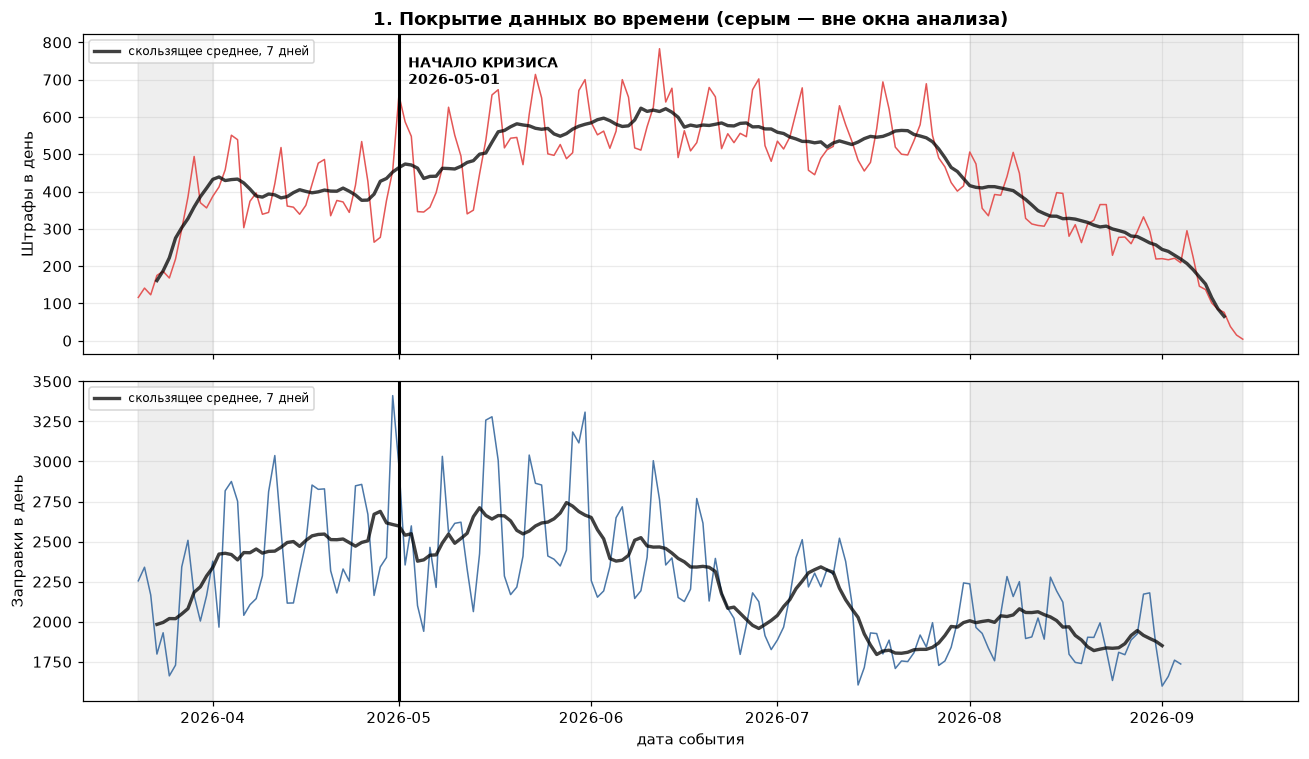

In [38]:
# 1. Покрытие во времени: видны и разгон слева, и цензурирование справа.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, col, ttl, c in [(axes[0], 'n_fines', 'Штрафы в день', '#E45756'),
                        (axes[1], 'n_refuels', 'Заправки в день', '#4C78A8')]:
    ax.plot(daily['date'], daily[col], lw=1.0, color=c)
    ax.plot(daily['date'], daily[col].rolling(7, center=True).mean(), lw=2.2, color='black',
            alpha=0.75, label='скользящее среднее, 7 дней')
    shade_window(ax); mark_boundary(ax, label=(ax is axes[0]))
    ax.set_ylabel(ttl); ax.legend(loc='upper left', fontsize=8)
axes[0].set_title('1. Покрытие данных во времени (серым — вне окна анализа)', fontweight='bold')
axes[1].set_xlabel('дата события')
finish(fig, '01_coverage_over_time.png', 'Покрытие данных во времени с майской границей')

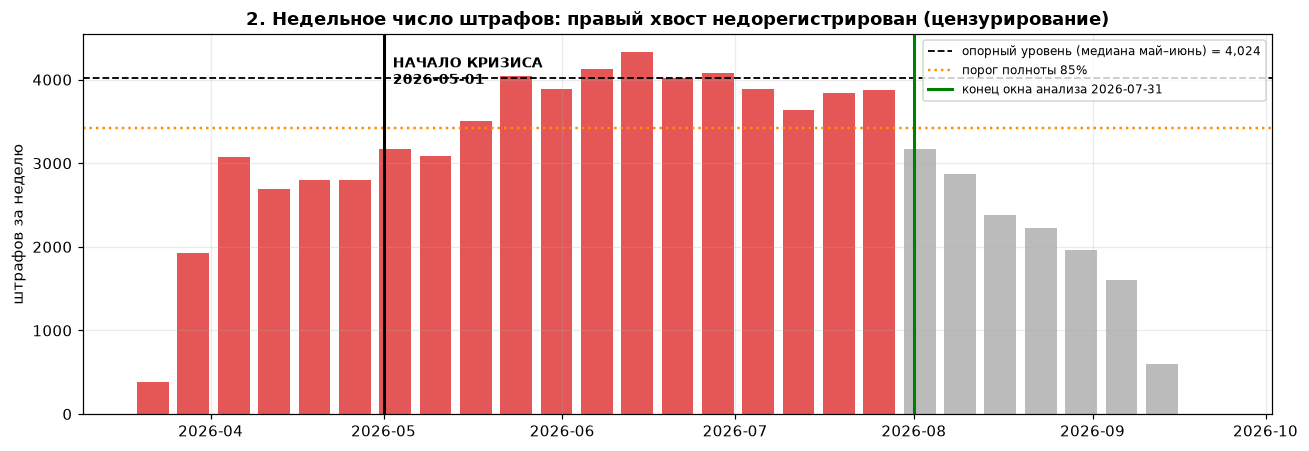

In [39]:
# 2. Диагностика цензурирования: почему правая граница окна именно такая.
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(fines_weekly.index, fines_weekly.values, width=5.5,
       color=np.where(fines_weekly.index <= ANALYSIS_END, '#E45756', '#BBBBBB'))
ax.axhline(REFERENCE_LEVEL, color='black', ls='--', lw=1.2,
           label=f'опорный уровень (медиана май–июнь) = {REFERENCE_LEVEL:,.0f}')
ax.axhline(REFERENCE_LEVEL * COMPLETENESS_THRESHOLD, color='darkorange', ls=':', lw=1.6,
           label=f'порог полноты {COMPLETENESS_THRESHOLD:.0%}')
ax.axvline(ANALYSIS_END, color='green', lw=2, label=f'конец окна анализа {ANALYSIS_END.date()}')
mark_boundary(ax)
ax.set_title('2. Недельное число штрафов: правый хвост недорегистрирован (цензурирование)',
             fontweight='bold')
ax.set_ylabel('штрафов за неделю'); ax.legend(fontsize=8)
finish(fig, '02_fines_censoring_diagnostic.png', 'Диагностика правого цензурирования штрафов')

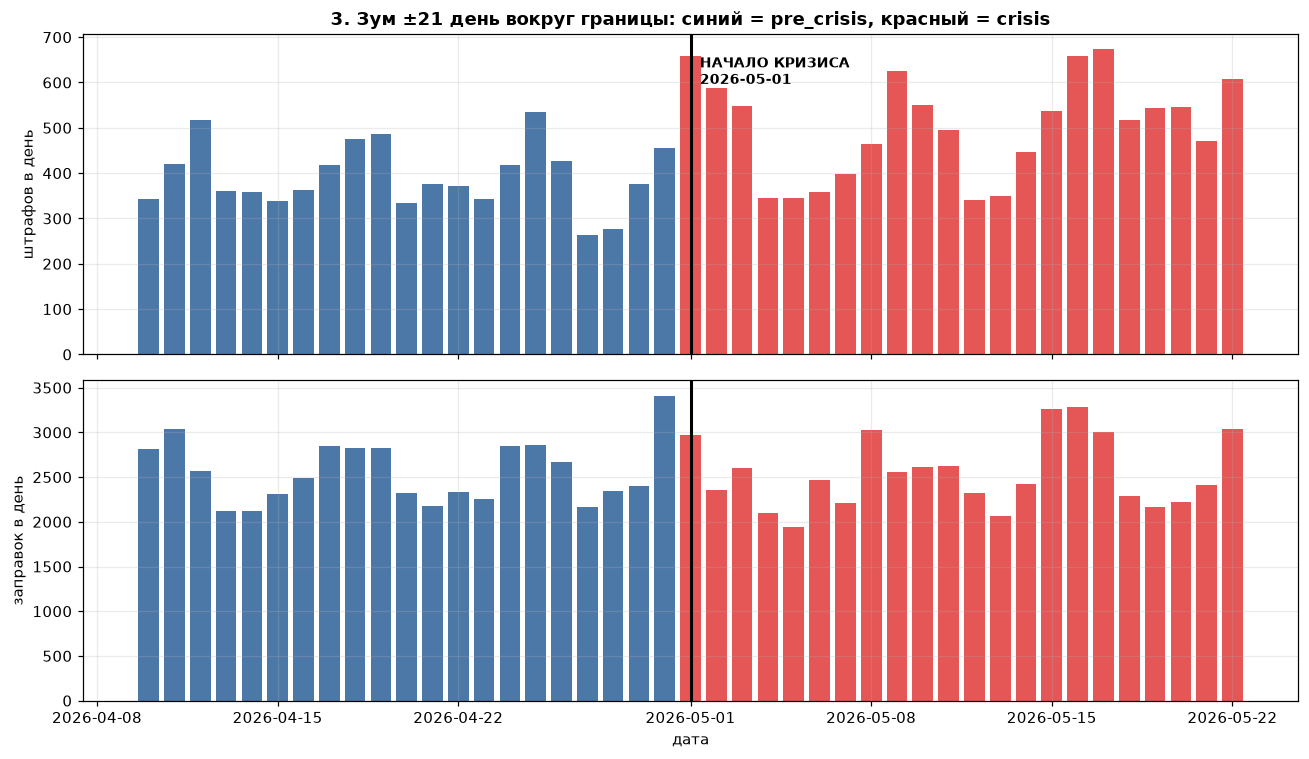

In [40]:
# 3. Зум на границу ±21 день: цвет = присвоенный период. Любая «протечка»
#    классификации через 1 мая была бы видна как точка чужого цвета.
zoom = daily[(daily['date'] >= CRISIS_START - pd.Timedelta(days=21)) &
             (daily['date'] <= CRISIS_START + pd.Timedelta(days=21))]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, col, ttl in [(axes[0], 'n_fines', 'штрафов в день'),
                     (axes[1], 'n_refuels', 'заправок в день')]:
    colors = np.where(zoom['period'] == 'crisis', CRISIS_COLOR, PRE_COLOR)
    ax.bar(zoom['date'], zoom[col], color=colors, width=0.8)
    mark_boundary(ax, label=(ax is axes[0]))
    ax.set_ylabel(ttl)
axes[0].set_title('3. Зум ±21 день вокруг границы: синий = pre_crisis, красный = crisis',
                  fontweight='bold')
axes[1].set_xlabel('дата')
finish(fig, '03_boundary_zoom.png', 'Зум на майскую границу: проверка классификации')

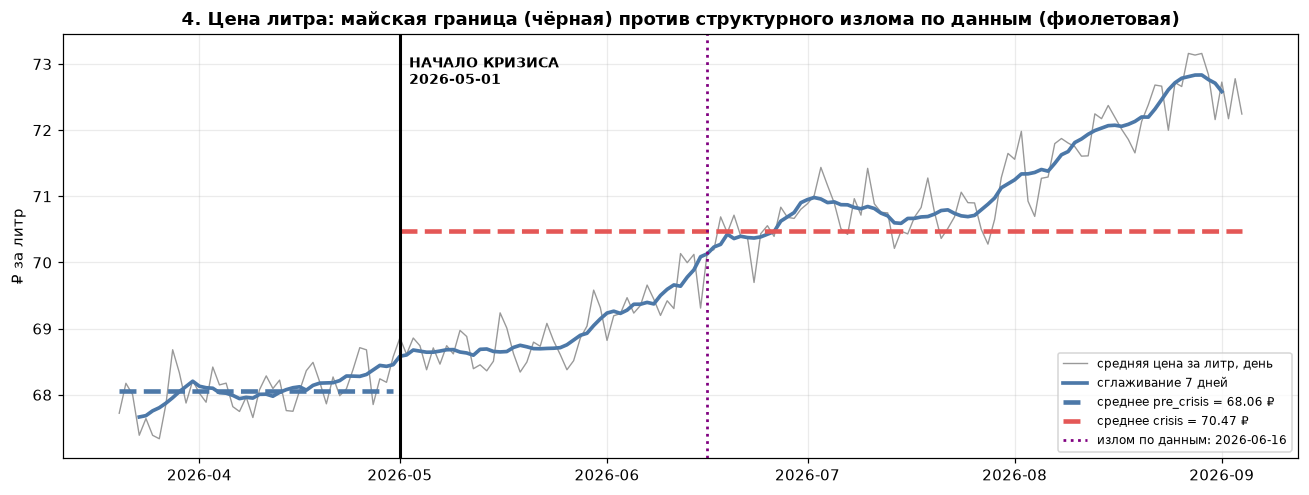

{'data_driven_price_break': '2026-06-16',
 'note': 'Структурный излом цены по данным НЕ используется для классификации; граница задана спецификацией задачи (май 2026).'}

In [41]:
# 4. Цена топлива: реагирует ли ряд на майскую границу, и где реальный излом.
#    Излом оценивается простым перебором точек разрыва по среднему уровню —
#    это ДИАГНОСТИКА, классификация периодов от неё не зависит.
s = daily.dropna(subset=['mean_price_rub_per_l']).set_index('date')['mean_price_rub_per_l']
cand = s.index[(s.index >= s.index.min() + pd.Timedelta(days=21)) &
               (s.index <= s.index.max() - pd.Timedelta(days=21))]
sse = {d: ((s[s.index < d] - s[s.index < d].mean()) ** 2).sum() +
          ((s[s.index >= d] - s[s.index >= d].mean()) ** 2).sum() for d in cand}
DATA_DRIVEN_BREAK = min(sse, key=sse.get)

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(s.index, s.values, lw=0.9, color='#999999', label='средняя цена за литр, день')
ax.plot(s.index, s.rolling(7, center=True).mean(), lw=2.4, color='#4C78A8', label='сглаживание 7 дней')
for lbl, seg in [('pre_crisis', s[s.index < CRISIS_START]), ('crisis', s[s.index >= CRISIS_START])]:
    ax.hlines(seg.mean(), seg.index.min(), seg.index.max(),
              color=PRE_COLOR if lbl == 'pre_crisis' else CRISIS_COLOR,
              lw=3, ls='--', label=f'среднее {lbl} = {seg.mean():.2f} ₽')
ax.axvline(DATA_DRIVEN_BREAK, color='purple', lw=1.8, ls=':',
           label=f'излом по данным: {DATA_DRIVEN_BREAK.date()}')
mark_boundary(ax)
ax.set_title('4. Цена литра: майская граница (чёрная) против структурного излома по данным (фиолетовая)',
             fontweight='bold')
ax.set_ylabel('₽ за литр'); ax.legend(fontsize=8, loc='lower right')
finish(fig, '04_fuel_price_with_boundary.png', 'Цена топлива и майская граница')
record('diagnostics', data_driven_price_break=str(DATA_DRIVEN_BREAK.date()),
       note='Структурный излом цены по данным НЕ используется для классификации; '
            'граница задана спецификацией задачи (май 2026).')

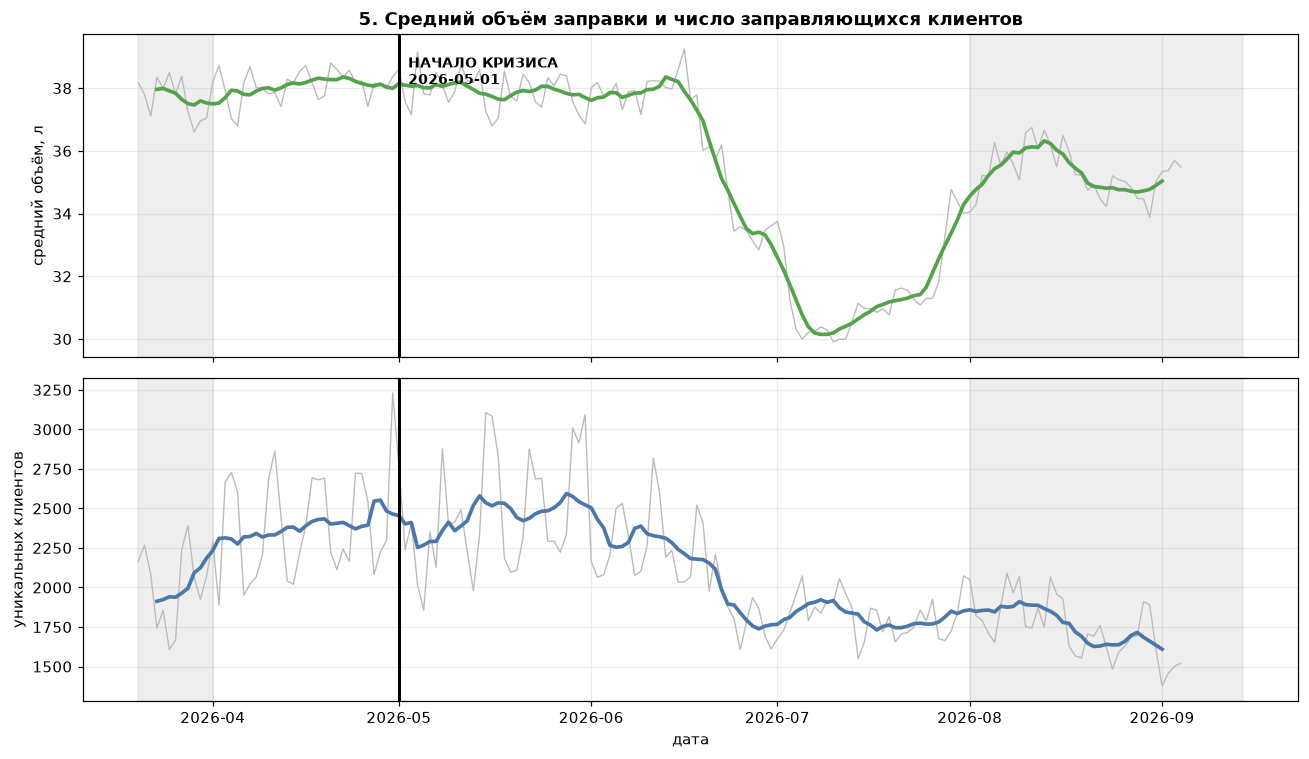

In [42]:
# 5. Объём одной заправки и число заправок — ключевые индикаторы дефицита.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(daily['date'], daily['mean_volume_l'], lw=0.9, color='#BBBBBB')
axes[0].plot(daily['date'], daily['mean_volume_l'].rolling(7, center=True).mean(), lw=2.4, color='#54A24B')
axes[0].set_ylabel('средний объём, л')
axes[1].plot(daily['date'], daily['n_clients_refuelling'], lw=0.9, color='#BBBBBB')
axes[1].plot(daily['date'], daily['n_clients_refuelling'].rolling(7, center=True).mean(), lw=2.4, color='#4C78A8')
axes[1].set_ylabel('уникальных клиентов'); axes[1].set_xlabel('дата')
for ax in axes:
    shade_window(ax); mark_boundary(ax, label=(ax is axes[0]))
axes[0].set_title('5. Средний объём заправки и число заправляющихся клиентов', fontweight='bold')
finish(fig, '05_fuel_volume_and_refuels.png', 'Объём заправки и активность клиентов')

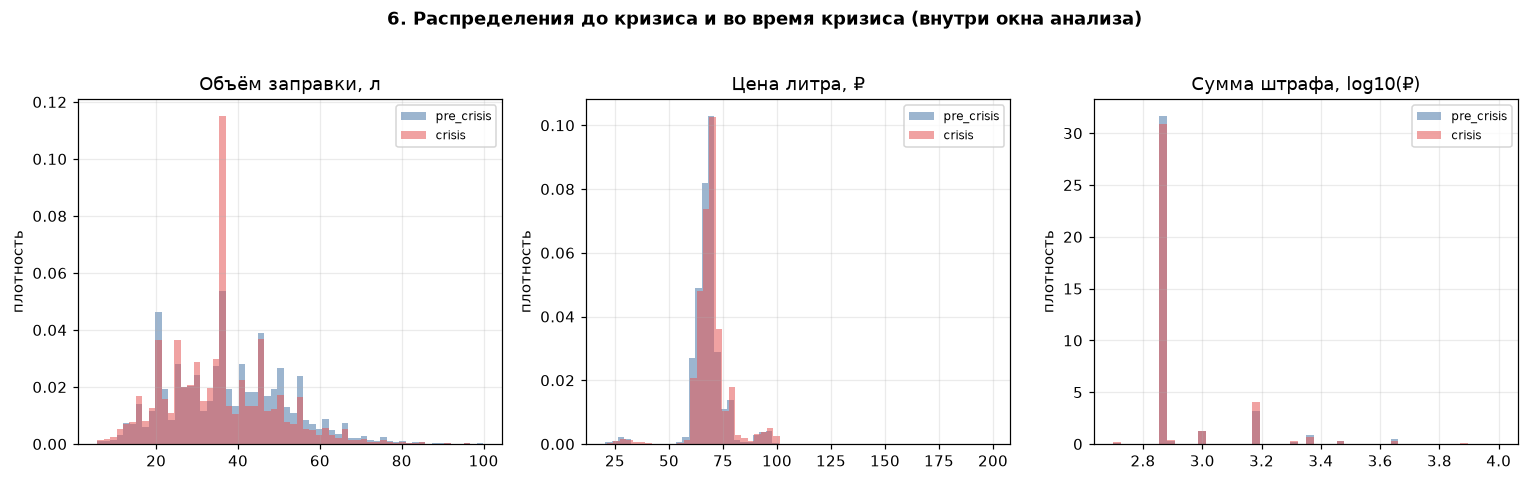

In [43]:
# 6. Распределения до и во время кризиса (не только средние).
win_fuel = ev_win[(ev_win['source_table'] == 'fuel') & ev_win['valid_measurement']]
win_fines = ev_win[ev_win['source_table'] == 'fines']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for per, c in [('pre_crisis', PRE_COLOR), ('crisis', CRISIS_COLOR)]:
    v = win_fuel.loc[win_fuel['period'] == per, 'fuel_volume_l'].astype(float)
    axes[0].hist(v, bins=60, alpha=0.55, density=True, color=c, label=per)
    p = win_fuel.loc[win_fuel['period'] == per, 'fuel_price_rub_per_l'].astype(float)
    axes[1].hist(p, bins=60, alpha=0.55, density=True, color=c, label=per)
    a = win_fines.loc[win_fines['period'] == per, 'fine_amount_rub'].astype(float)
    axes[2].hist(np.log10(a[a > 0]), bins=50, alpha=0.55, density=True, color=c, label=per)

axes[0].set_title('Объём заправки, л'); axes[1].set_title('Цена литра, ₽')
axes[2].set_title('Сумма штрафа, log10(₽)')
for ax in axes:
    ax.legend(fontsize=8); ax.set_ylabel('плотность')
fig.suptitle('6. Распределения до кризиса и во время кризиса (внутри окна анализа)',
             fontweight='bold', y=1.03)
finish(fig, '06_distributions_pre_vs_crisis.png', 'Распределения до/во время кризиса')

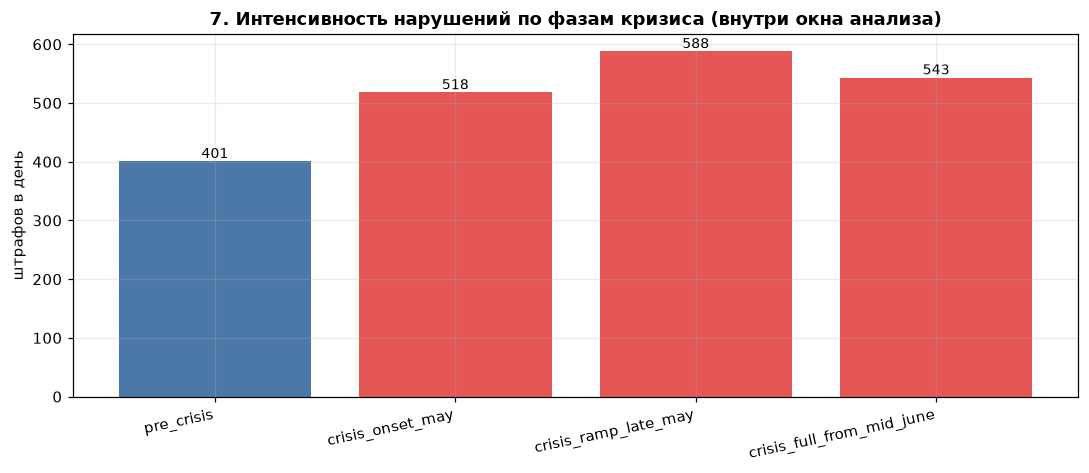

In [44]:
# 7. Интенсивность штрафов по фазам — согласуется ли с разворачиванием кризиса.
phase_days = (events[events['in_analysis_window']]
              .groupby('crisis_phase', observed=True)['event_date'].nunique())
phase_fines = (events[events['in_analysis_window'] & (events['source_table'] == 'fines')]
               .groupby('crisis_phase', observed=True).size())
phase_rate = (phase_fines / phase_days).dropna()

fig, ax = plt.subplots(figsize=(10, 4.4))
colors = [PRE_COLOR if p == 'pre_crisis' else CRISIS_COLOR for p in phase_rate.index]
bars = ax.bar([str(p) for p in phase_rate.index], phase_rate.values, color=colors)
ax.bar_label(bars, fmt='%.0f', fontsize=9)
ax.set_ylabel('штрафов в день'); ax.set_title(
    '7. Интенсивность нарушений по фазам кризиса (внутри окна анализа)', fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=12, ha='right')
finish(fig, '07_fines_by_phase.png', 'Интенсивность штрафов по фазам кризиса')

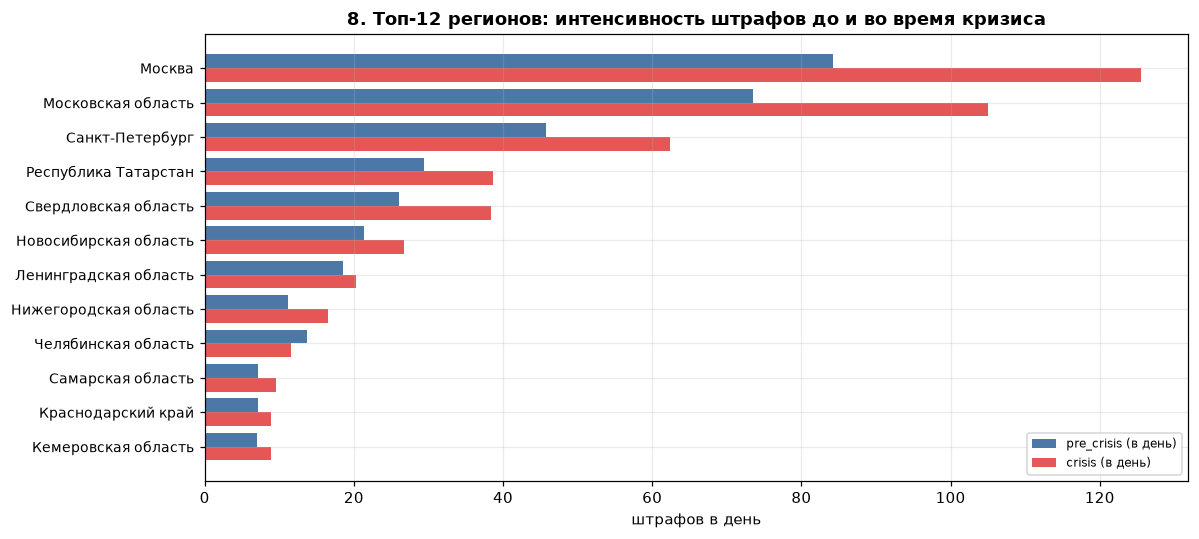

In [45]:
# 8. Региональный срез: если бы классификация «поехала» в каком-то регионе,
#    его столбец выбился бы из общей картины.
top_regions = win_fines['offence_region'].value_counts().head(12).index
reg = (win_fines[win_fines['offence_region'].isin(top_regions)]
       .groupby(['offence_region', 'period'], observed=True).size().unstack('period'))
reg.columns = [str(c) for c in reg.columns]
reg = reg.div(pd.Series(PERIOD_DAYS)).loc[top_regions]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(reg)); w = 0.4
ax.barh(x - w / 2, reg['pre_crisis'], height=w, color=PRE_COLOR, label='pre_crisis (в день)')
ax.barh(x + w / 2, reg['crisis'], height=w, color=CRISIS_COLOR, label='crisis (в день)')
ax.set_yticks(x); ax.set_yticklabels(reg.index, fontsize=9); ax.invert_yaxis()
ax.set_xlabel('штрафов в день'); ax.legend(fontsize=8)
ax.set_title('8. Топ-12 регионов: интенсивность штрафов до и во время кризиса', fontweight='bold')
finish(fig, '08_regional_split.png', 'Региональный срез до/во время кризиса')

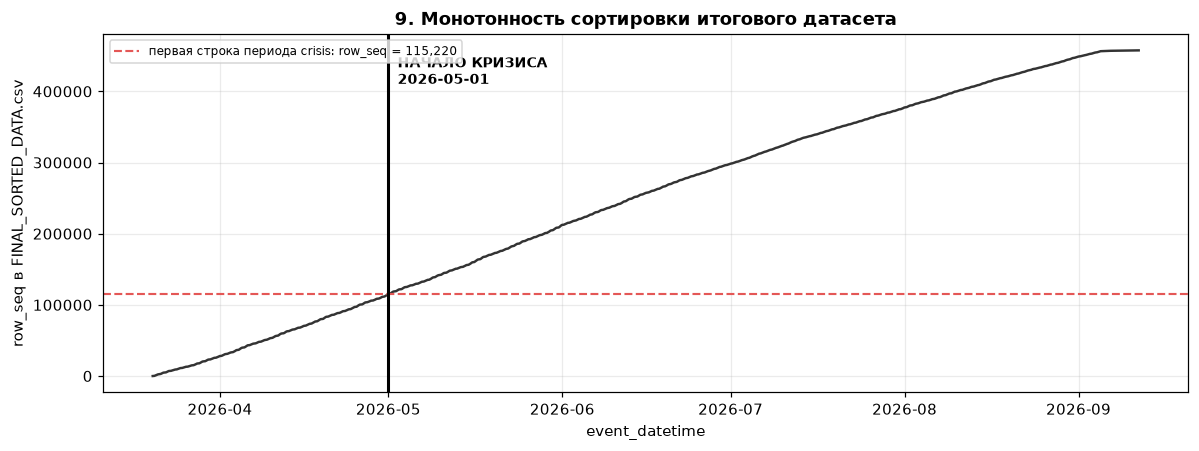

In [46]:
# 9. Прямая проверка сортировки: row_seq против времени должен быть
#    неубывающей кривой без единого «отката» назад.
step = max(len(events) // 4000, 1)
sample = events.iloc[::step]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(sample['event_datetime'], sample['row_seq'], lw=1.6, color='#333333')
crisis_start_seq = int(events.loc[events['period'] == 'crisis', 'row_seq'].min())
ax.axhline(crisis_start_seq, color=CRISIS_COLOR, ls='--', lw=1.4,
           label=f'первая строка периода crisis: row_seq = {crisis_start_seq:,}')
mark_boundary(ax)
ax.set_xlabel('event_datetime'); ax.set_ylabel('row_seq в FINAL_SORTED_DATA.csv')
ax.set_title('9. Монотонность сортировки итогового датасета', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
finish(fig, '09_sort_monotonicity.png', 'Монотонность сортировки итогового датасета')

## 11. Экспорт финальных датасетов

Сырые файлы не трогаются. Всё пишется в отдельный каталог `FINAL_OUTPUT/`.

* **`FINAL_SORTED_DATA.csv`** — главный результат. Одна строка = одно событие
  (штраф **или** заправка), отсортировано хронологически, у каждой строки
  проставлены `period`, `crisis_phase`, `censoring_flag`, `in_analysis_window`.
* **`FINAL_SORTED_FINES.csv`** / **`FINAL_SORTED_FUEL.csv`** — те же события,
  но в исходной табличной форме, со всеми родными колонками и флагами очистки.
* **`FINAL_CLIENT_PERIOD_PANEL.csv`** — агрегаты «клиент × период» внутри окна
  анализа, нормированные на 30 дней. Именно этот файл идёт в модель.
* **`FINAL_DAILY_SERIES.csv`** — дневные ряды обеих таблиц.
* **`FINAL_BOUNDARY_VALIDATION.csv`** — таблица периодов с явной границей.

In [47]:
CSV_KW = dict(index=False, encoding='utf-8-sig')

EXPORTS = {}

events_export = events.copy()
events_export['event_datetime'] = events_export['event_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S.%f').str[:-3]
events_export['event_date'] = events_export['event_date'].dt.strftime('%Y-%m-%d')
EXPORTS['FINAL_SORTED_DATA.csv'] = events_export

fines_export = fines_sorted.drop(columns=['event_month']).copy()
fines_export['event_datetime'] = fines_export['event_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
fines_export['event_date'] = fines_export['event_date'].dt.strftime('%Y-%m-%d')
EXPORTS['FINAL_SORTED_FINES.csv'] = fines_export

fuel_export = fuel_sorted.drop(columns=['event_month']).copy()
fuel_export['event_datetime'] = fuel_export['event_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S.%f').str[:-3]
fuel_export['event_date'] = fuel_export['event_date'].dt.strftime('%Y-%m-%d')
EXPORTS['FINAL_SORTED_FUEL.csv'] = fuel_export

EXPORTS['FINAL_CLIENT_PERIOD_PANEL.csv'] = panel
daily_export = daily.copy()
daily_export['date'] = daily_export['date'].dt.strftime('%Y-%m-%d')
EXPORTS['FINAL_DAILY_SERIES.csv'] = daily_export

boundary_export = pd.concat([
    PERIOD_TABLE.assign(scope='all_data'),
    PERIOD_TABLE_WINDOW.assign(scope='analysis_window'),
    PHASE_TABLE.rename(columns={'crisis_phase': 'period'}).assign(scope='phases', boundary_used=str(CRISIS_START)),
], ignore_index=True)
EXPORTS['FINAL_BOUNDARY_VALIDATION.csv'] = boundary_export

for fname, df in EXPORTS.items():
    df.to_csv(OUT_DIR / fname, **CSV_KW)
    print(f'{fname:<34} {len(df):>9,} строк  {df.shape[1]:>3} колонок  '
          f'{(OUT_DIR / fname).stat().st_size / 1e6:>7.1f} МБ')

FINAL_SORTED_DATA.csv                457,677 строк   26 колонок    125.1 МБ


FINAL_SORTED_FINES.csv                77,978 строк   19 колонок     25.3 МБ


FINAL_SORTED_FUEL.csv                379,699 строк   21 колонок     95.1 МБ


FINAL_CLIENT_PERIOD_PANEL.csv         51,350 строк   23 колонок      8.9 МБ
FINAL_DAILY_SERIES.csv                   179 строк   15 колонок      0.0 МБ
FINAL_BOUNDARY_VALIDATION.csv              8 строк   12 колонок      0.0 МБ


In [48]:
# --- V7. Выгруженные файлы соответствуют датафреймам ноутбука --------------
EXPORT_INFO = {}
for fname, df in EXPORTS.items():
    path = OUT_DIR / fname
    back = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    check(f'V7.{fname}', f'{fname}: форма файла совпадает с датафреймом',
          back.shape == df.shape and list(back.columns) == list(df.columns),
          detail=f'{back.shape} vs {df.shape}')
    EXPORT_INFO[fname] = {'rows': len(back), 'cols': back.shape[1],
                          'bytes': path.stat().st_size, 'sha256': sha256_of(path)}

back_main = pd.read_csv(OUT_DIR / 'FINAL_SORTED_DATA.csv', encoding='utf-8-sig', low_memory=False)
check('V7.1', 'FINAL_SORTED_DATA.csv: множество event_id совпадает с датафреймом',
      set(back_main['event_id']) == set(events['event_id']), detail='')
check('V7.2', 'FINAL_SORTED_DATA.csv: распределение по периодам совпадает с датафреймом',
      {str(k): int(v) for k, v in back_main['period'].value_counts().items()} ==
      {str(k): int(v) for k, v in events['period'].value_counts().items()},
      detail=back_main['period'].value_counts().to_dict())
check('V7.3', 'FINAL_SORTED_DATA.csv: порядок строк сохранён (row_seq монотонен)',
      bool(back_main['row_seq'].is_monotonic_increasing) and
      bool(pd.to_datetime(back_main['event_datetime']).is_monotonic_increasing),
      detail='')
check('V7.4', 'FINAL_SORTED_DATA.csv: сумма штрафов и объёма топлива совпадает с датафреймом',
      abs(float(back_main['fine_amount_rub'].sum()) - float(events['fine_amount_rub'].astype('Float64').sum())) < 0.01
      and abs(float(back_main['fuel_volume_l'].sum()) - float(events['fuel_volume_l'].astype('Float64').sum())) < 0.01,
      detail='')

record('outputs', directory=str(OUT_DIR), files=EXPORT_INFO,
       figures={k: str(FIG_DIR / k) for k in FIGURES})
pd.DataFrame(EXPORT_INFO).T

[PASS] V7.FINAL_SORTED_DATA.csv: FINAL_SORTED_DATA.csv: форма файла совпадает с датафреймом  |  (457677, 26) vs (457677, 26)


[PASS] V7.FINAL_SORTED_FINES.csv: FINAL_SORTED_FINES.csv: форма файла совпадает с датафреймом  |  (77978, 19) vs (77978, 19)


[PASS] V7.FINAL_SORTED_FUEL.csv: FINAL_SORTED_FUEL.csv: форма файла совпадает с датафреймом  |  (379699, 21) vs (379699, 21)
[PASS] V7.FINAL_CLIENT_PERIOD_PANEL.csv: FINAL_CLIENT_PERIOD_PANEL.csv: форма файла совпадает с датафреймом  |  (51350, 23) vs (51350, 23)
[PASS] V7.FINAL_DAILY_SERIES.csv: FINAL_DAILY_SERIES.csv: форма файла совпадает с датафреймом  |  (179, 15) vs (179, 15)
[PASS] V7.FINAL_BOUNDARY_VALIDATION.csv: FINAL_BOUNDARY_VALIDATION.csv: форма файла совпадает с датафреймом  |  (8, 12) vs (8, 12)


[PASS] V7.1: FINAL_SORTED_DATA.csv: множество event_id совпадает с датафреймом
[PASS] V7.2: FINAL_SORTED_DATA.csv: распределение по периодам совпадает с датафреймом  |  {'crisis': 342458, 'pre_crisis': 115219}
[PASS] V7.3: FINAL_SORTED_DATA.csv: порядок строк сохранён (row_seq монотонен)
[PASS] V7.4: FINAL_SORTED_DATA.csv: сумма штрафов и объёма топлива совпадает с датафреймом


,rows,cols,bytes,sha256
FINAL_SORTED_DATA.csv,457677,26,125055598,1d7bfaf6e8c3bd8681a30242594a9fafb49f61baf2202cef046505b7...
FINAL_SORTED_FINES.csv,77978,19,25341987,3e20e13c79f0ac9331e4cb2e21a422f02169838e7bc6e9e06b06395e...
FINAL_SORTED_FUEL.csv,379699,21,95137341,49ee2ef95ee2d94aa1d205b89dff8806ee36b4bd5d33334ba2226e74...
FINAL_CLIENT_PERIOD_PANEL.csv,51350,23,8864854,978bede1ecfd487a83c6c1a56cc588ad2a68b4008b4591634191bf2c...
FINAL_DAILY_SERIES.csv,179,15,27011,571e5c175347943898784b0be5b1abfcdf2f011ac79c0a240d33939d...
FINAL_BOUNDARY_VALIDATION.csv,8,12,1096,40cc52c20f0dd221f037bb01eef8bd1fcffc75d70238e607e7b48db8...


In [49]:
# --- Сырые файлы не изменились ---------------------------------------------
RAW_HASHES_AFTER = {name: sha256_of(p) for name, p in RAW_PATHS.items()}
check('V8.1', 'СЫРЫЕ ФАЙЛЫ НЕ ИЗМЕНЕНЫ: SHA-256 до и после совпадают',
      RAW_HASHES_BEFORE == RAW_HASHES_AFTER,
      detail=', '.join(f'{k}: {v[:12]}…' for k, v in RAW_HASHES_AFTER.items()))

[PASS] V8.1: СЫРЫЕ ФАЙЛЫ НЕ ИЗМЕНЕНЫ: SHA-256 до и после совпадают  |  clients_demographics.csv: c41797f050d2…, fines_2026.csv: 1de7495a11ac…, fuel_transaction.csv: 977e9a2d5175…


True

## 12. Генерация аудит-лога

`FINAL_SORTING_AUDIT.md` собирается **из объектов, полученных при выполнении**
(`AUDIT`, `VALIDATIONS`, `EXPORT_INFO`), а не набирается руками. Поэтому лог
физически не может разойтись с тем, что ноутбук на самом деле сделал:
если изменится результат — изменится и лог.

In [50]:
# Допущения и аномалии — единственный «ручной» текст в логе; всё остальное
# вычислено. Каждый пункт привязан к конкретному наблюдению в данных.
ASSUMPTIONS = [
    f'**Граница кризиса = {CRISIS_START}.** Организаторы прямо пишут «Начало кризиса: май 2026» '
    '(Презентация задания new.pdf) и просят сравнить динамику «до и после мая 2026 года» '
    '(Задание.pdf). Взята полночь 1 мая; интервал левозакрытый.',

    'Формулировка «с конца мая... к середине июня» из Задание.pdf трактуется как описание '
    'разворачивания кризиса, а не как сдвиг его начала. Она отражена в отдельной колонке '
    '`crisis_phase` и НЕ меняет деление pre_crisis / crisis.',

    'Метки времени в данных не содержат таймзоны и трактуются как единая локальная шкала; '
    'сдвиги не применялись. Граница сравнивается в той же шкале.',

    f'`total_fine_amount` интерпретируется как копейки (по ТЗ) и делится на 100: медиана '
    f"{AUDIT['cleaning_fines']['amount_rub_median']:,.0f} ₽ — правдоподобный размер штрафа ГИБДД.",

    'Отсутствие штрафа у клиента — не пропуск и не выброс, а ноль (прямо оговорено в ТЗ). '
    'В панели такие клиенты присутствуют с `n_fines = 0`, а не выпадают из неё.',

    'Демографические признаки (пол, возрастная группа, kladr) проверены на постоянство внутри '
    'клиента и только затем свёрнуты к уровню клиента; счётчики штрафов 2025 суммированы по '
    'всем автомобилям клиента.',

    f'Окно анализа {ANALYSIS_START.date()} … {ANALYSIS_END.date()} выбрано для сопоставимости '
    'периодов; строки вне окна сохранены с флагом, а не удалены.',

    'Пороги правдоподобия (объём заправки 0.1–100 л, цена 10–200 ₽/л) заданы из физических '
    'соображений, а не подобраны по данным; они только помечают строки.',
]

ANOMALIES = [
    f'**Предыдущая версия сортировки использовала границу 2026-06-19** — это противоречит '
    f'постановке задачи. Здесь граница пересчитана на {CRISIS_START.date()}, и вся '
    'классификация построена заново от сырых файлов.',

    f'**Структурный излом цены топлива по данным приходится на '
    f"{AUDIT['diagnostics']['data_driven_price_break']}, а не на 1 мая.** Это ожидаемо: "
    'ограничения вводились постепенно с конца мая. Факт зафиксирован как диагностика '
    '(график 04) и как таблица устойчивости; на классификацию он не влияет — граница задана '
    'спецификацией. Для DiD-оценок это аргумент в пользу учёта фаз `crisis_phase`.',

    f'**Расхождение со спецификацией по окнам данных.** ТЗ описывает таблицу 2 как '
    f'«апрель–август 2026», фактически штрафы идут с {fines["event_datetime"].min().date()} по '
    f'{fines["event_datetime"].max().date()}; таблица 3 — с {fuel["event_datetime"].min().date()} по '
    f'{fuel["event_datetime"].max().date()}. Строки сохранены, но помечены.',

    f'**Правое цензурирование штрафов.** Недельное число нарушений монотонно падает начиная с '
    f"недели {AUDIT['analysis_window']['first_censored_week']} и обрушивается в сентябре — это "
    'лаг регистрации постановлений, а не поведение водителей. Интерпретировать август–сентябрь '
    'как «снижение аварийности» нельзя.',

    f'**Разгон на левом крае.** Первые дни выгрузки (с '
    f'{fines["event_datetime"].min().date()}) дают заниженное число штрафов, поэтому окно '
    'анализа начинается с первого полного месяца.',

    f'**Докризисный период короткий:** {AUDIT["analysis_window"]["pre_days"]} дней против '
    f'{AUDIT["analysis_window"]["crisis_days"]} кризисных внутри окна. Это ограничение данных, '
    'а не выбор: до апреля наблюдений просто нет. Сезонность апреля vs лета остаётся '
    'альтернативным объяснением и требует контроля (например, счётчиками штрафов 2025 года '
    'из таблицы 1).',

    f'**Отрицательные объёмы в таблице 3:** '
    f'{AUDIT["cleaning_fuel"]["n_flag_negative_volume"]:,} строк с объёмом < 0 '
    '(медиана около -36 л), равномерно по месяцам — похоже на возвраты/сторно заказов. '
    f'Без отдельной обработки у {int((panel["fuel_volume_l_net_all"] < 0).sum())} пар '
    '«клиент × период» суммарный объём получался бы отрицательным. '
    'Проверка V6.5 ловит это как ошибку, а не пропускает молча.',

    f'**Многомодальная цена литра.** Сегменты: {AUDIT["cleaning_fuel"]["price_segments"]}. '
    'Кластер ниже 45 руб/л похож на газовое топливо (ГБО), хвост выше 150 руб/л — на иной '
    'продукт либо ошибки ввода. Сравнение средних цен «до / во время кризиса» без удержания '
    'сегмента постоянным может отражать сдвиг топливной корзины, а не подорожание; '
    'для этого в данных есть колонка `price_segment`.',

    f'**Объёмы свыше 100 л:** {int((fuel["order_fuel_volume"] > 100).sum()):,} строк '
    f'(максимум {AUDIT["cleaning_fuel"]["volume_max"]:.0f} л) — вероятно коммерческий транспорт '
    'или агрегированные заказы; помечены как некорректные измерения.',

    f'**Демография неполна:** пол отсутствует у {int(raw_clients["gender"].isna().sum())} строк, '
    f'цена автомобиля — у {int(raw_clients["price"].isna().sum())}, цвет — у '
    f'{int(raw_clients["color"].isna().sum())}. Для периодизации это значения не имеет, '
    'но важно при построении модели с контрольными переменными.',
]

print(f'Допущений: {len(ASSUMPTIONS)}, аномалий: {len(ANOMALIES)}')

Допущений: 8, аномалий: 10


In [51]:
def fmt_kv_table(d, k_title='параметр', v_title='значение'):
    lines = [f'| {k_title} | {v_title} |', '|---|---|']
    for k, v in d.items():
        lines.append(f'| `{k}` | {v} |')
    return '\n'.join(lines)


def fmt_cell(v):
    if v is None or (isinstance(v, float) and np.isnan(v)) or v is pd.NaT:
        return ''
    if isinstance(v, (int, np.integer)):
        return f'{v:,}'
    if isinstance(v, (float, np.floating)):
        return f'{v:,.4g}'
    return str(v).replace('|', '\\|')


def fmt_df(df):
    'Markdown-таблица без внешних зависимостей (tabulate не требуется).'
    cols = [str(c) for c in df.columns]
    head = '| ' + ' | '.join(cols) + ' |'
    sep = '|' + '|'.join(['---'] * len(cols)) + '|'
    body = ['| ' + ' | '.join(fmt_cell(v) for v in row) + ' |'
            for row in df.itertuples(index=False, name=None)]
    return '\n'.join([head, sep] + body)


L = []
A = L.append

A(f'# FINAL SORTING AUDIT — Топливный кризис 2026\n')
A(f'> Автоматически сгенерировано ноутбуком `{NOTEBOOK_NAME}` при выполнении.')
A(f'> Ручных правок в этом файле нет: все числа — результат исполнения кода.\n')

A('## 0. Паспорт запуска\n')
A(fmt_kv_table({
    'notebook': NOTEBOOK_NAME,
    'timestamp обработки': AUDIT['environment']['run_started_at'],
    'timestamp записи лога': datetime.now().astimezone().isoformat(timespec='seconds'),
    'рабочий каталог': str(BASE_DIR),
    'каталог выгрузки': str(OUT_DIR),
    'python': AUDIT['environment']['python'],
    'pandas': AUDIT['environment']['pandas'],
    'numpy': AUDIT['environment']['numpy'],
    'matplotlib': AUDIT['environment']['matplotlib'],
    'платформа': AUDIT['environment']['platform'],
}))

A('\n## 1. Входные файлы (сырые, только чтение)\n')
A(fmt_df(RAW_FILE_INFO))
A('\nSHA-256 пересчитаны в конце выполнения и совпали с исходными — '
  'сырые файлы не изменялись.\n')

A('## 2. Число строк до и после обработки\n')
rows_tbl = pd.DataFrame([
    {'таблица': 'clients_demographics.csv (сырая, клиент × авто)',
     'строк на входе': RAW_ROWS['clients_demographics.csv'],
     'строк на выходе': len(clients_cars), 'удалено': 0},
    {'таблица': 'clients (свёрнута к уровню клиента)',
     'строк на входе': RAW_ROWS['clients_demographics.csv'],
     'строк на выходе': len(clients),
     'удалено': 0},
    {'таблица': 'fines_2026.csv → FINAL_SORTED_FINES.csv',
     'строк на входе': RAW_ROWS['fines_2026.csv'],
     'строк на выходе': len(fines_sorted), 'удалено': 0},
    {'таблица': 'fuel_transaction.csv → FINAL_SORTED_FUEL.csv',
     'строк на входе': RAW_ROWS['fuel_transaction.csv'],
     'строк на выходе': len(fuel_sorted), 'удалено': 0},
    {'таблица': 'объединённые события → FINAL_SORTED_DATA.csv',
     'строк на входе': RAW_ROWS['fines_2026.csv'] + RAW_ROWS['fuel_transaction.csv'],
     'строк на выходе': len(events), 'удалено': 0},
])
A(fmt_df(rows_tbl))
A('\n**Строки не удалялись ни на одном шаге.** Свёртка клиентской таблицы '
  f'({len(clients_cars):,} → {len(clients):,}) — не удаление, а агрегация '
  '«клиент × автомобиль» → «клиент»: у части клиентов несколько машин.\n')

A('## 3. Использованные и созданные колонки\n')
A('**Колонки-источники, от которых зависит классификация:**\n')
A(fmt_kv_table({
    'fines_2026.bill_offence_date': 'дата-время нарушения — ключевая колонка периодизации штрафов',
    'fuel_transaction.order_datetime': 'дата-время заказа — ключевая колонка периодизации заправок',
    'fines_2026.bill_id / fuel_transaction.order_id': 'идентификаторы, ключи сортировки и проверки дублей',
    'fines_2026.total_fine_amount': 'сумма штрафа в копейках',
    'fuel_transaction.order_fuel_volume / order_fuel_price_1liter': 'объём и цена литра',
    'clients_demographics.client_id / auto_document_id': 'ключи связи',
    'clients_demographics.gender / age_type_code / kladr_code': 'демография (постоянна внутри клиента — проверено)',
}, 'колонка', 'роль'))
A('\n**Созданные колонки:**\n')
A(fmt_kv_table({
    'event_datetime': 'разобранная дата-время события',
    'event_date / event_month': 'календарные срезы',
    'period': 'pre_crisis / crisis по границе ' + str(CRISIS_START),
    'crisis_phase': 'четырёхфазная детализация кризиса',
    'days_from_crisis_start': 'смещение в днях относительно границы (для event-study)',
    'censoring_flag': 'left_edge_ramp_in / complete / right_censored_suspected',
    'in_analysis_window': 'булев флаг попадания в окно анализа',
    'row_seq': 'порядковый номер строки в итоговой сортировке (1…N)',
    'fine_amount_rub': 'сумма штрафа в рублях = total_fine_amount / 100',
    'fuel_cost_rub': 'стоимость чека = объём × цена литра',
    'home_region': 'регион регистрации по kladr_code (справочник из ТЗ)',
    'flag_* ': 'флаги качества: битая/отсутствующая/невозможная дата, сомнительные объём и цена',
}, 'колонка', 'смысл'))

A('\n## 4. Правила разбора дат\n')
A(fmt_df(date_parse_report))
A(f"\nПолитика: `{AUDIT['date_parsing']['policy']}`.\n")
A(f"Последнее событие во всех данных (≈ момент выгрузки): **{DATA_EXTRACT_AT}**. "
  f"Даты вне диапазона `[{PLAUSIBLE_MIN.date()}, {DATA_EXTRACT_AT}]` помечались как невозможные: "
  f"штрафы — {AUDIT['observed_windows']['n_impossible_fines']}, "
  f"заправки — {AUDIT['observed_windows']['n_impossible_fuel']}.\n")

A('## 5. ГРАНИЦА КРИЗИСА\n')
A(f'> **Точная граница: `{CRISIS_START}`**\n')
A(f"> **Правило: `{AUDIT['crisis_definition']['rule']}`**\n")
A(f"> **Соглашение об интервале: {AUDIT['crisis_definition']['interval_convention']}**\n")
A('\nОснование — постановка задачи:\n')
for q in AUDIT['crisis_definition']['source_quotes']:
    A(f'* {q}')
A('\nФазы внутри кризиса (уточнение, не замена границы):\n')
A(fmt_kv_table(AUDIT['crisis_definition']['phases'], 'фаза', 'интервал'))

A('\n## 6. Окно анализа и цензурирование\n')
A(f"**Окно: `{ANALYSIS_START}` … `{ANALYSIS_END}`**\n")
A(f"Правило выбора: {AUDIT['analysis_window']['rule']}\n")
A(fmt_kv_table({
    'опорный недельный уровень штрафов': AUDIT['analysis_window']['reference_weekly_level'],
    'порог полноты': AUDIT['analysis_window']['completeness_threshold'],
    'пиковая неделя': AUDIT['analysis_window']['peak_week'],
    'первая неделя с недобором регистрации': AUDIT['analysis_window']['first_censored_week'],
    'дней в pre_crisis внутри окна': AUDIT['analysis_window']['pre_days'],
    'дней в crisis внутри окна': AUDIT['analysis_window']['crisis_days'],
}))
A('\nСтроки вне окна **не удалены** — они помечены `in_analysis_window = False`:\n')
A(fmt_df(events['censoring_flag'].value_counts().rename('строк').rename_axis('censoring_flag').reset_index()))

A('\n## 7. Ключи сортировки\n')
A(f"Порядок: {' → '.join(AUDIT['sorting']['sort_keys'])}, все по возрастанию. "
  f"Алгоритм: {AUDIT['sorting']['algorithm']} — результат воспроизводим между запусками.\n")
A('Для `FINAL_SORTED_FINES.csv` использована пара `event_datetime → bill_id`, '
  'для `FINAL_SORTED_FUEL.csv` — `event_datetime → order_id`.\n')

A('## 8. Логика классификации и группировки\n')
A('```python\n'
  'period = "crisis"      если event_datetime >= CRISIS_START\n'
  'period = "pre_crisis"  если event_datetime <  CRISIS_START\n'
  'period = <NA>          если event_datetime is NaT\n'
  '```\n')
A('Группировки: панель — `groupby(client_id, period)` внутри окна анализа, с '
  'достройкой полного индекса «все клиенты × оба периода» и заполнением нулями '
  '(отсутствие штрафа — не пропуск, а ноль: прямо оговорено в ТЗ). '
  'Дневные ряды — `groupby(event_date)` отдельно по каждой таблице.\n')

A('## 9. Удалённые строки, пропуски, аномалии\n')
A(f'**Удалено строк: 0.** Политика — помечать, а не удалять.\n')
A('Пропуски в сырых данных:\n')
miss = pd.concat([
    raw_clients.isna().sum().rename('clients_demographics'),
    raw_fines.isna().sum().rename('fines_2026'),
    raw_fuel.isna().sum().rename('fuel_transaction'),
], axis=1).fillna(0).astype(int)
miss = miss[(miss.T != 0).any()]
A(fmt_df(miss.rename_axis('колонка').reset_index()))
A(f"\nБитых дат: штрафы — {AUDIT['date_parsing']['report'][0]['n_malformed']}, "
  f"заправки — {AUDIT['date_parsing']['report'][1]['n_malformed']}. "
  f"Отсутствующих дат: {AUDIT['date_parsing']['report'][0]['n_missing_raw']} и "
  f"{AUDIT['date_parsing']['report'][1]['n_missing_raw']} соответственно.\n")
A('### Сомнительные измерения в таблице 3 (строки сохранены, помечены флагом)\n')
A(fmt_kv_table({
    'строк с отрицательным объёмом (сторно/возврат)': f"{AUDIT['cleaning_fuel']['n_flag_negative_volume']:,}",
    'строк с объёмом вне (0; 100] л': f"{AUDIT['cleaning_fuel']['n_flag_bad_volume']:,}",
    'строк с ценой вне [10; 200] руб/л': f"{AUDIT['cleaning_fuel']['n_flag_bad_price']:,}",
    'строк, годных для измерений (valid_measurement)':
        f"{AUDIT['cleaning_fuel']['n_valid_measurement']:,} "
        f"({AUDIT['cleaning_fuel']['pct_valid_measurement']}%)",
    'сегменты цены литра': AUDIT['cleaning_fuel']['price_segments'],
    'диапазон объёма, л': f"{AUDIT['cleaning_fuel']['volume_min']} … {AUDIT['cleaning_fuel']['volume_max']}",
    'диапазон цены, руб/л': f"{AUDIT['cleaning_fuel']['price_min']} … {AUDIT['cleaning_fuel']['price_max']}",
    'неположительных сумм штрафа': AUDIT['cleaning_fines']['n_nonpositive_amount'],
}, 'показатель', 'значение'))
A('\nЭти флаги **не влияют на периодизацию** — период определяется только датой. '
  'Они влияют на агрегаты: литры, траты и средние цены в панели и дневных рядах '
  'считаются только по строкам с `valid_measurement = True`. Для полноты в панели '
  'сохранена и знаковая сумма `fuel_volume_l_net_all`, включающая сторно-строки.\n')

A('### Обработка дубликатов\n')
A(fmt_df(dup_report))
A('\n`client_id` в таблице 1 повторяется по конструкции (клиент × автомобиль), '
  f"уникальна пара `client_id + auto_document_id`; клиентов с несколькими машинами — "
  f"{AUDIT['key_linkage']['n_clients_with_multiple_cars']:,}. "
  'Поэтому демография присоединялась к событиям только после свёртки к уровню клиента '
  '(`validate="many_to_one"`), иначе заправки таких клиентов размножились бы.\n')

A('## 10. Результат классификации\n')
A('**Все данные:**\n')
A(fmt_df(PERIOD_TABLE))
A('\n**Внутри окна анализа (сопоставимые периоды):**\n')
A(fmt_df(PERIOD_TABLE_WINDOW))
A('\n**По фазам:**\n')
A(fmt_df(PHASE_TABLE))
A('\n**Сводная статистика:**\n')
A(fmt_df(SUMMARY_TABLE))
A('\n**Устойчивость к выбору границы** (диагностика; классификация построена только по 2026-05-01):\n')
A(fmt_df(SENSITIVITY_TABLE))

A('\n## 11. Выполненные проверки\n')
vdf = pd.DataFrame(VALIDATIONS)
vdf['результат'] = np.where(vdf['passed'], 'PASS', 'FAIL')
A(fmt_df(vdf[['id', 'description', 'результат', 'detail']]
         .rename(columns={'id': 'код', 'description': 'что проверено', 'detail': 'подробности'})))
A(f'\nВсего проверок: **{len(vdf)}**, пройдено: **{int(vdf["passed"].sum())}**, '
  f'провалено: **{int((~vdf["passed"]).sum())}**.\n')

A('## 12. Выходные файлы\n')
out_tbl = pd.DataFrame(EXPORT_INFO).T.rename_axis('файл').reset_index()
out_tbl['описание'] = out_tbl['файл'].map({
    'FINAL_SORTED_DATA.csv': 'ГЛАВНЫЙ РЕЗУЛЬТАТ: все события (штрафы + заправки), хронологическая сортировка, метки периодов',
    'FINAL_SORTED_FINES.csv': 'Таблица 2 целиком: очищена, даты разобраны, периоды проставлены',
    'FINAL_SORTED_FUEL.csv': 'Таблица 3 целиком: очищена, даты разобраны, периоды проставлены',
    'FINAL_CLIENT_PERIOD_PANEL.csv': 'Панель «клиент × период» внутри окна анализа, метрики на 30 дней — вход для модели',
    'FINAL_DAILY_SERIES.csv': 'Дневные агрегаты обеих таблиц с метками периода',
    'FINAL_BOUNDARY_VALIDATION.csv': 'Таблица периодов: period / start / end / number_of_rows',
})
A(fmt_df(out_tbl))
A('\n**Графики:**\n')
A(fmt_kv_table(FIGURES, 'файл', 'на какой вопрос отвечает'))

A('\n## 13. Принятые допущения\n')
for i, a in enumerate(ASSUMPTIONS, 1):
    A(f'{i}. {a}')

A('\n## 14. Обнаруженные аномалии и предупреждения\n')
for i, w in enumerate(ANOMALIES, 1):
    A(f'{i}. {w}')

A('\n---\n')
A('### Как воспроизвести\n')
A(f'1. Открыть `{NOTEBOOK_NAME}` в каталоге `{BASE_DIR}`.\n'
  f'2. Kernel → Restart Kernel and Run All Cells.\n'
  f'3. Ноутбук перечитает сырые CSV, пересоберёт всё с нуля и перезапишет '
  f'содержимое `FINAL_OUTPUT/`, включая этот лог. Любая провалённая проверка '
  f'останавливает выполнение исключением.\n')

print(f'Аудит-лог собран: {len(L)} блоков.')

Аудит-лог собран: 94 блоков.


In [52]:
AUDIT_PATH = OUT_DIR / 'FINAL_SORTING_AUDIT.md'
AUDIT_PATH.write_text('\n'.join(L), encoding='utf-8')

# Машиночитаемая копия фактов — на случай, если лог захотят разобрать программно.
AUDIT_JSON_PATH = OUT_DIR / 'FINAL_SORTING_AUDIT.json'
AUDIT_JSON_PATH.write_text(
    json.dumps({'audit': AUDIT, 'validations': VALIDATIONS,
                'assumptions': ASSUMPTIONS, 'anomalies': ANOMALIES},
               ensure_ascii=False, indent=2, default=str), encoding='utf-8')

check('V9.1', 'аудит-лог записан и непуст',
      AUDIT_PATH.exists() and AUDIT_PATH.stat().st_size > 5000,
      detail=f'{AUDIT_PATH} — {AUDIT_PATH.stat().st_size:,} байт')
print(AUDIT_PATH)
print(AUDIT_JSON_PATH)

[PASS] V9.1: аудит-лог записан и непуст  |  /Users/markmitrofanov/Desktop/DANO dataset/FINAL_OUTPUT/FINAL_SORTING_AUDIT.md — 33,698 байт
/Users/markmitrofanov/Desktop/DANO dataset/FINAL_OUTPUT/FINAL_SORTING_AUDIT.md
/Users/markmitrofanov/Desktop/DANO dataset/FINAL_OUTPUT/FINAL_SORTING_AUDIT.json


## 13. Финальная сверка

Ответы на контрольные вопросы считаются из итоговых объектов прямо здесь —
ничего не переписано руками.

In [53]:
n_pre = int((events['period'] == 'pre_crisis').sum())
n_cri = int((events['period'] == 'crisis').sum())
n_pre_w = int(((events['period'] == 'pre_crisis') & events['in_analysis_window']).sum())
n_cri_w = int(((events['period'] == 'crisis') & events['in_analysis_window']).sum())
n_misclassified = int(((events['event_datetime'] < CRISIS_START) & (events['period'] == 'crisis')).sum() +
                      ((events['event_datetime'] >= CRISIS_START) & (events['period'] == 'pre_crisis')).sum())
n_malformed = int(fines['flag_malformed_date'].sum() + fuel['flag_malformed_date'].sum())
n_missing = int(fines['flag_missing_date'].sum() + fuel['flag_missing_date'].sum())
n_dupes = int(events.duplicated(['source_table', 'event_id']).sum())
rows_in = RAW_ROWS['fines_2026.csv'] + RAW_ROWS['fuel_transaction.csv']

ANSWERS = [
    ('Начинается ли кризис в мае согласно постановке задачи?',
     'ДА. «Начало кризиса: май 2026» (Презентация задания new.pdf); «динамика ... до и после мая 2026 года» (Задание.pdf).'),
    ('Какая именно граница использована?',
     f'{CRISIS_START} — crisis ⇔ event_datetime >= границы (интервал левозакрытый).'),
    ('Сколько наблюдений докризисных?',
     f'{n_pre:,} во всех данных; {n_pre_w:,} внутри окна анализа ({ANALYSIS_START.date()} … {ANALYSIS_END.date()}).'),
    ('Сколько наблюдений кризисных?',
     f'{n_cri:,} во всех данных; {n_cri_w:,} внутри окна анализа.'),
    ('Есть ли наблюдения, классифицированные через границу неверно?',
     f'НЕТ — {n_misclassified} (проверки V2.2, V2.3, V2.4, V3.5, V2.7, V2.8).'),
    ('Сходится ли число строк?',
     f'ДА: {rows_in:,} строк на входе = {len(events):,} строк в FINAL_SORTED_DATA.csv (V1.1–V1.3).'),
    ('Потеряны ли строки?',
     'НЕТ. Удалено 0 строк: всё сомнительное помечено флагами, а не удалено.'),
    ('Продублированы ли строки?',
     f'НЕТ — дублей (source_table, event_id): {n_dupes}; множества идентификаторов совпадают с сырыми файлами (V4.4).'),
    ('Были ли битые или отсутствующие даты?',
     f'НЕТ: битых — {n_malformed}, отсутствующих — {n_missing}; разобрано 100% дат обеих событийных таблиц.'),
    ('Соответствует ли выгруженный датасет проверенному датафрейму?',
     f'ДА — файлы перечитаны с диска и сверены по форме, идентификаторам, периодам, порядку и суммам (V7.*).'),
]

print('=' * 100)
for q, a in ANSWERS:
    print(f'• {q}\n  → {a}\n')
print('=' * 100)

• Начинается ли кризис в мае согласно постановке задачи?
  → ДА. «Начало кризиса: май 2026» (Презентация задания new.pdf); «динамика ... до и после мая 2026 года» (Задание.pdf).

• Какая именно граница использована?
  → 2026-05-01 00:00:00 — crisis ⇔ event_datetime >= границы (интервал левозакрытый).

• Сколько наблюдений докризисных?
  → 115,219 во всех данных; 87,126 внутри окна анализа (2026-04-01 … 2026-07-31).

• Сколько наблюдений кризисных?
  → 342,458 во всех данных; 262,170 внутри окна анализа.

• Есть ли наблюдения, классифицированные через границу неверно?
  → НЕТ — 0 (проверки V2.2, V2.3, V2.4, V3.5, V2.7, V2.8).

• Сходится ли число строк?
  → ДА: 457,677 строк на входе = 457,677 строк в FINAL_SORTED_DATA.csv (V1.1–V1.3).

• Потеряны ли строки?
  → НЕТ. Удалено 0 строк: всё сомнительное помечено флагами, а не удалено.

• Продублированы ли строки?
  → НЕТ — дублей (source_table, event_id): 0; множества идентификаторов совпадают с сырыми файлами (V4.4).

• Были ли битые или 

In [54]:
vdf = pd.DataFrame(VALIDATIONS)
n_pass, n_fail = int(vdf['passed'].sum()), int((~vdf['passed']).sum())

print(f'ПРОВЕРОК ВЫПОЛНЕНО: {len(vdf)}   PASS: {n_pass}   FAIL: {n_fail}')
print()
print('ВЫХОДНЫЕ ФАЙЛЫ в', OUT_DIR)
for p in sorted(OUT_DIR.glob('*')):
    if p.is_file():
        print(f'  {p.name:<34} {p.stat().st_size / 1e6:>8.2f} МБ')
print(f'  figures/ — {len(list(FIG_DIR.glob("*.png")))} графиков')
print()
check('V9.2', 'ИТОГ: все проверки ноутбука пройдены', n_fail == 0,
      detail=f'{n_pass}/{len(vdf)}')
print()
print(f'Граница кризиса: {CRISIS_START} — МАЙ. Пересборка завершена.')

ПРОВЕРОК ВЫПОЛНЕНО: 54   PASS: 54   FAIL: 0

ВЫХОДНЫЕ ФАЙЛЫ в /Users/markmitrofanov/Desktop/DANO dataset/FINAL_OUTPUT
  FINAL_BOUNDARY_VALIDATION.csv          0.00 МБ
  FINAL_CLIENT_PERIOD_PANEL.csv          8.86 МБ
  FINAL_DAILY_SERIES.csv                 0.03 МБ
  FINAL_SORTED_DATA.csv                125.06 МБ
  FINAL_SORTED_FINES.csv                25.34 МБ
  FINAL_SORTED_FUEL.csv                 95.14 МБ
  FINAL_SORTING_AUDIT.json               0.03 МБ
  FINAL_SORTING_AUDIT.md                 0.03 МБ
  figures/ — 9 графиков

[PASS] V9.2: ИТОГ: все проверки ноутбука пройдены  |  54/54

Граница кризиса: 2026-05-01 00:00:00 — МАЙ. Пересборка завершена.
